# Laboratorio 7 — Spark MLlib con la ENEIC (Personas)

**CC3066 Data Science, segundo semestre de 2026.**

Este notebook es la entrega final complementaria. Todos los resultados provienen de la ejecución real de `lab7_final.py` dentro de Docker (Python 3.11, Java 17, PySpark 3.5.1) sobre los cinco libros oficiales de Personas de la ENEIC. El notebook **no reentrena ni recalcula**: carga las tablas JSON y las figuras PNG persistidas en `outputs/`, que fueron verificadas por los comandos `--validate-*` de cada fase, y **muestra el código real de Spark** que las produjo, leído directamente de `lab7_final.py`.

El avance previo (`main7.py` y `lab7.ipynb`) se conserva sin cambios en el repositorio; sus cifras preliminares no se usan aquí porque se calcularon con 4,000 filas por período y con una partición aleatoria.

Flujo reproducible:

| Fase | Comando | Resultado persistido |
|---|---|---|
| Fundación | `--foundation`, `--validate-foundation` | `outputs/foundation/`, Parquet 2025 y 2026 |
| EDA y KMeans | `--eda-clustering`, `--validate-eda-clustering` | `outputs/eda/` |
| Selección temporal | `--models-validation`, `--validate-models-validation` | `outputs/models/` |
| Prueba final 2026 | `--final-test`, `--validate-final-test` | `outputs/test_2026/` |
| Entrega | `--validate-delivery` | `outputs/delivery/` |

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
OUT = ROOT / "outputs"
if not (OUT / "foundation" / "manifest.json").exists():
    raise FileNotFoundError("El notebook debe ejecutarse desde la raíz del repositorio.")

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def load(relative_path):
    return json.loads((OUT / relative_path).read_text(encoding="utf-8"))


def figure(relative_path):
    display(Image(filename=str(OUT / relative_path)))


validations = {
    "Fundación": "foundation/validation_foundation.json",
    "EDA y clustering": "eda/validation_eda_clustering.json",
    "Selección temporal": "models/validation_models_validation.json",
    "Prueba final 2026": "test_2026/validation_final_test.json",
}
pd.DataFrame(
    [
        {"fase": name, "ok": load(path)["ok"], "controles": load(path)["controles_aprobados"], "fallas": len(load(path)["fallas"])}
        for name, path in validations.items()
    ]
).set_index("fase")

,ok,controles,fallas
fase,,,
Fundación,True,353,0
EDA y clustering,True,149,0
Selección temporal,True,63,0
Prueba final 2026,True,245,0


Las cuatro fases quedaron validadas sin fallas. Cada validación relee únicamente artefactos persistidos: conteos, llaves, esquemas, métricas recalculadas desde las predicciones y modelos recargados desde disco.

In [2]:
import ast
import hashlib

from IPython.display import Markdown

import lab7_final as lab

SOURCE_PATH = ROOT / "lab7_final.py"
SOURCE_TEXT = SOURCE_PATH.read_text(encoding="utf-8")
SOURCE_LINES = SOURCE_TEXT.splitlines()
SOURCE_FUNCTIONS = {
    node.name: (node.lineno, node.end_lineno)
    for node in ast.parse(SOURCE_TEXT).body
    if isinstance(node, ast.FunctionDef)
}


def show_code(*names):
    for name in names:
        start, end = SOURCE_FUNCTIONS[name]
        fragment = "\n".join(SOURCE_LINES[start - 1:end])
        display(Markdown(f"**`lab7_final.py`, líneas {start}–{end}: `{name}`**\n\n```python\n{fragment}\n```"))


pd.DataFrame(
    [{"funcion": name, "linea_inicio": start, "linea_fin": end} for name, (start, end) in SOURCE_FUNCTIONS.items()]
).set_index("funcion").loc[
    ["read_workbook", "typed_frame", "filter_steps", "apply_filters", "consolidate", "summarize_numeric", "pearson_matrix",
     "compare_kmeans", "linear_pipeline", "forest_pipeline", "fit_candidates", "frozen_configurations", "error_table", "high_salary_analysis"]
]

,linea_inicio,linea_fin
funcion,,
read_workbook,484,532
typed_frame,595,603
filter_steps,648,684
apply_filters,687,698
consolidate,906,928
summarize_numeric,1277,1302
pearson_matrix,1379,1386
compare_kmeans,1404,1433
linear_pipeline,2029,2051


### Cómo se muestra el código real

La función `show_code` lee `lab7_final.py` como texto, localiza cada función con el módulo `ast` y muestra sus líneas exactas con resaltado Python. No ejecuta Spark, no llama a `.fit()` y no lee datos: es el mismo código que produjo los artefactos de `outputs/`. En cada inciso aparece el fragmento correspondiente a la API de Spark utilizada.

### Versión del código y hashes

Cada fase guardó en su resumen un campo `codigo_sha256` con la huella del archivo `lab7_final.py` tal como existía cuando se ejecutó esa fase. Como el mismo archivo se amplió después con las fases siguientes (EDA, modelos, prueba final y validación de entrega), el hash global cambió en cada ampliación y no coincide con el del archivo actual. Eso no invalida los resultados: la validez de cada fase se comprobó con su propio comando `--validate-*`, que relee los artefactos persistidos, recalcula métricas desde las predicciones y recarga los modelos guardados. Las funciones que generaron cada fase no se modificaron al agregar las siguientes.

In [3]:
phase_hashes = {
    "Fundación": load("foundation/manifest.json")["codigo_sha256"],
    "EDA y clustering": load("eda/eda_summary.json")["codigo_sha256"],
    "Selección temporal": load("models/models_validation_summary.json")["codigo_sha256"],
    "Prueba final 2026": load("test_2026/final_test_summary.json")["codigo_sha256"],
    "lab7_final.py actual": hashlib.sha256(SOURCE_PATH.read_bytes()).hexdigest(),
}
pd.Series(phase_hashes, name="codigo_sha256").to_frame()

,codigo_sha256
Fundación,fd0d12ccf63bd22699de479526f5ae0dd6570086f07af8...
EDA y clustering,a69f484c74d3f16a114a6a25902c939667a38a2df29891...
Selección temporal,30858f8fda9800be5abc5d7a11c17aeb848c70f8c297fd...
Prueba final 2026,6b3bc9ae34ed775b161529069f4124358a4d7e697ec336...
lab7_final.py actual,ff50e0b206666d12aa6c28712ae2917712d8a5fbe6a265...


## Ejercicio 1. Carga, procedencia, filtros y Parquet

Cada libro se leyó por separado, seleccionando por nombre solo las 14 columnas requeridas. Todo se leyó como texto y luego se convirtió de forma explícita, porque 2025T2 almacena 209 columnas como texto. El manifiesto registra hoja, filas, columnas, tamaño y hash SHA-256 de cada fuente.

In [4]:
show_code(
    "read_workbook",
    "normalize_cell",
    "finite_double",
    "integral_code",
    "typed_expression",
    "typed_frame",
    "tenure_expression",
    "filter_steps",
    "apply_filters",
    "code_label",
    "eligible_frame",
    "process_source",
    "union_periods",
    "consolidate",
)

**`lab7_final.py`, líneas 484–532: `read_workbook`**

```python
def read_workbook(path: Path, columns: tuple[str, ...] = REQUIRED_COLUMNS) -> WorkbookExtract:
    from openpyxl import load_workbook

    workbook = load_workbook(path, read_only=True, data_only=True)
    try:
        sheets = list(workbook.sheetnames)
        visible = [sheet.title for sheet in workbook.worksheets if sheet.sheet_state == "visible"]
        if len(visible) != 1:
            raise FoundationError(f"{path.name}: se esperaba una hoja visible y se encontraron {visible}")
        rows_iterator = workbook[visible[0]].iter_rows(values_only=True)
        header_row = next(rows_iterator, None)
        if header_row is None:
            raise FoundationError(f"{path.name}: hoja sin encabezado")
        header = [normalize_header(value) for value in header_row]
        while header and header[-1] is None:
            header.pop()
        names = [name for name in header if name is not None]
        duplicates = sorted({name for name in names if names.count(name) > 1})
        missing = [column for column in columns if column not in header]
        if missing:
            raise FoundationError(f"{path.name}: faltan columnas requeridas {missing}")
        if any(column in duplicates for column in columns):
            raise FoundationError(f"{path.name}: columnas requeridas duplicadas {duplicates}")
        indexes = [header.index(column) for column in columns]
        width = len(header)
        rows: list[tuple[Any, ...]] = []
        skipped = 0
        excel_row = 1
        for raw in rows_iterator:
            excel_row += 1
            if raw is None or all(is_blank(value) for value in raw[:width]):
                skipped += 1
                continue
            rows.append(
                tuple(normalize_cell(raw[index]) if index < len(raw) else None for index in indexes) + (excel_row,)
            )
        return WorkbookExtract(
            hoja=visible[0],
            hojas=sheets,
            hojas_visibles=visible,
            columnas_encabezado=width,
            encabezados_vacios=len(header) - len(names),
            encabezados_duplicados=duplicates,
            filas_datos=len(rows),
            filas_vacias_omitidas=skipped,
            rows=rows,
        )
    finally:
        workbook.close()
```

**`lab7_final.py`, líneas 460–477: `normalize_cell`**

```python
def normalize_cell(value: Any) -> str | None:
    if value is None:
        return None
    if isinstance(value, bool):
        return str(int(value))
    if isinstance(value, int):
        return str(value)
    if isinstance(value, float):
        if not math.isfinite(value):
            return None
        return str(int(value)) if value.is_integer() else repr(value)
    text = str(value).strip()
    if text.lower() in SENTINELS:
        return None
    if THOUSANDS_TEXT.match(text):
        text = text.replace(",", "")
    integral = INTEGRAL_TEXT.match(text)
    return integral.group(1) if integral else text
```

**`lab7_final.py`, líneas 560–564: `finite_double`**

```python
def finite_double(column: str):
    from pyspark.sql import functions as F

    value = F.col(column).cast("double")
    return F.when(value.isNotNull() & ~F.isnan(value) & (F.abs(value) < F.lit(float("inf"))), value)
```

**`lab7_final.py`, líneas 567–571: `integral_code`**

```python
def integral_code(column: str, data_type: str):
    from pyspark.sql import functions as F

    value = finite_double(column)
    return F.when(value == F.floor(value), value.cast(data_type))
```

**`lab7_final.py`, líneas 574–579: `typed_expression`**

```python
def typed_expression(column: str):
    if column in LONG_CODE_COLUMNS:
        return integral_code(column, "bigint")
    if column in INTEGER_CODE_COLUMNS:
        return integral_code(column, "int")
    return finite_double(column)
```

...

**`lab7_final.py`, líneas 701–704: `code_label`**

```python
def code_label(column: str, codes: tuple[int, ...]):
    from pyspark.sql import functions as F

    return F.when(F.col(column).isin(*codes), F.col(column).cast("string")).otherwise(F.lit(UNKNOWN_LABEL))
```

**`lab7_final.py`, líneas 707–735: `eligible_frame`**

```python
def eligible_frame(filtered):
    from pyspark.sql import functions as F

    return filtered.select(
        F.concat_ws(
            "_", F.col("periodo_archivo"), F.col("NUM_HOGAR").cast("string"), F.col("NUM_PERSONA").cast("string")
        ).alias("id_registro"),
        "archivo_origen",
        "periodo_archivo",
        "anio_archivo",
        "trimestre_calendario",
        "fila_origen",
        "ANIO",
        "TRIMESTRE",
        "NUM_HOGAR",
        "NUM_PERSONA",
        "FACTOR",
        F.col("P02A03").alias("edad"),
        tenure_expression().alias("antiguedad"),
        F.col("P05H01A").alias("horas_semanales"),
        F.col("P05D01").alias("salario_mensual"),
        code_label("P03A03A", ELIGIBLE_CODES["nivel_educativo"]).alias("nivel_educativo"),
        code_label("P05C16", ELIGIBLE_CODES["categoria_ocupacional"]).alias("categoria_ocupacional"),
        code_label("DOMINIO", ELIGIBLE_CODES["dominio"]).alias("dominio"),
        "P03A03A",
        "P05C16",
        F.col("DOMINIO").alias("codigo_dominio"),
        "OCUPADOS",
    )
```

**`lab7_final.py`, líneas 824–895: `process_source`**

```python
def process_source(spark, source: SourceSpec, digest: str) -> dict[str, Any]:
    started = time.perf_counter()
    print(f"[{source.periodo}] leyendo {source.archivo} (solo {len(REQUIRED_COLUMNS)} columnas)")
    extract = read_workbook(source.path)
    rows = extract.rows
    extract.rows = []
    print(f"[{source.periodo}] filas={extract.filas_datos} columnas={extract.columnas_encabezado} hoja={extract.hoja!r}")
    raw_frame = with_provenance(spark.createDataFrame(rows, schema=raw_schema()), source)
    del rows
    gc.collect()
    typed = None
    filtered = None
    try:
        from pyspark import StorageLevel

        raw_frame = raw_frame.persist(StorageLevel.MEMORY_AND_DISK)
        missing, invalid = raw_quality(raw_frame)
        typed = typed_frame(raw_frame).persist(StorageLevel.MEMORY_AND_DISK)
        typed.write.mode("overwrite").parquet(str(SELECTED_DIR / source.periodo))
        raw_frame.unpersist()
        keys = key_audit(typed)
        quarter = value_counts(typed, "TRIMESTRE")
        year = value_counts(typed, "ANIO")
        codes = {column: value_counts(typed, column) for column in AUDITED_CODES}
        unrecognized = unrecognized_codes(typed)
        filtered, steps = apply_filters(typed)
        eligible = eligible_frame(filtered).persist(StorageLevel.MEMORY_AND_DISK)
        eligible.write.mode("overwrite").parquet(str(ELIGIBLE_PERIOD_DIR / source.periodo))
        eligible_count = eligible.count()
        unknown = unknown_counts(eligible)
        eligible.unpersist()
    finally:
        raw_frame.unpersist()
        if typed is not None:
            typed.unpersist()
        spark.catalog.clearCache()
        gc.collect()
    audit = {
        "periodo": source.periodo,
        "archivo": source.archivo,
        "sha256": digest,
        "bytes": source.path.stat().st_size,
        "mib": round(source.path.stat().st_size / MIB, 2),
        "hoja": extract.hoja,
        "hojas": extract.hojas,
        "hojas_visibles": extract.hojas_visibles,
        "columnas_encabezado": extract.columnas_encabezado,
        "encabezados_vacios": extract.encabezados_vacios,
        "encabezados_duplicados": extract.encabezados_duplicados,
        "filas_datos": extract.filas_datos,
        "filas_vacias_omitidas": extract.filas_vacias_omitidas,
        "columnas_requeridas": list(REQUIRED_COLUMNS),
        "anio_archivo": source.anio,
        "trimestre_calendario": source.trimestre,
        "faltantes_crudos": missing,
        "valores_no_convertibles": invalid,
        "trimestre_original": quarter,
        "anio_original_valores": year,
        "codigos_observados": codes,
        "codigos_no_reconocidos": unrecognized,
        "llaves": keys,
        "exclusiones": steps,
        "elegibles": eligible_count,
        "desconocidos_elegibles": unknown,
        "parquet_seleccion": relative(SELECTED_DIR / source.periodo),
        "parquet_elegibles": relative(ELIGIBLE_PERIOD_DIR / source.periodo),
        "segundos": round(time.perf_counter() - started, 1),
        "generado_utc": utc_now(),
    }
    write_json(PERIOD_AUDIT_DIR / f"{source.periodo}.json", audit)
    print(f"[{source.periodo}] elegibles={eligible_count} control={source.elegibles} ({audit['segundos']} s)")
    return audit
```

**`lab7_final.py`, líneas 898–903: `union_periods`**

```python
def union_periods(spark, base: Path, periods: list[str]):
    frames = [spark.read.parquet(str(base / period)) for period in periods]
    combined = frames[0]
    for frame in frames[1:]:
        combined = combined.unionByName(frame)
    return combined
```

**`lab7_final.py`, líneas 906–928: `consolidate`**

```python
def consolidate(spark) -> dict[str, Any]:
    from pyspark.sql import functions as F

    periods_2025 = [source.periodo for source in SOURCES if source.anio == 2025]
    periods_2026 = [source.periodo for source in SOURCES if source.anio == 2026]
    for periods, target in ((periods_2025, ELIGIBLE_2025), (periods_2026, ELIGIBLE_2026)):
        frame = union_periods(spark, ELIGIBLE_PERIOD_DIR, periods).orderBy("periodo_archivo", "fila_origen")
        frame.coalesce(1).write.mode("overwrite").parquet(str(target))
    selected = union_periods(spark, SELECTED_DIR, [source.periodo for source in SOURCES])
    total = selected.count()
    distinct_period_keys = selected.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA").distinct().count()
    repeated_pairs = (
        selected.groupBy("NUM_HOGAR", "NUM_PERSONA")
        .agg(F.countDistinct("periodo_archivo").alias("periodos"))
        .filter(F.col("periodos") > 1)
        .count()
    )
    return {
        "filas_seleccionadas_totales": total,
        "llaves_periodo_distintas": distinct_period_keys,
        "llaves_periodo_duplicadas": total - distinct_period_keys,
        "pares_hogar_persona_en_varios_periodos": repeated_pairs,
    }
```

Lectura del código anterior, en el orden en que se ejecutó:

1. **Carga:** `read_workbook` abre cada Excel con `openpyxl.load_workbook(read_only=True)`, busca las 14 columnas **por nombre** (`header.index(column)`) y convierte cada celda a texto normalizado con `normalize_cell`.
2. **DataFrame de Spark con tipos explícitos:** `process_source` crea el DataFrame con `spark.createDataFrame(rows, schema=raw_schema())` (todas las columnas como texto) y `typed_frame` aplica `cast("double")`, `F.floor` y `F.when` para obtener `int`, `bigint` o `double` finitos. Los valores no convertibles quedan nulos y se contabilizan.
3. **Filtros:** `filter_steps` define las seis condiciones y `apply_filters` las aplica en orden con `DataFrame.filter(F.coalesce(condición, False))`, registrando `count()` antes y después de cada paso.
4. **Parquet:** `process_source` usa `persist(StorageLevel.MEMORY_AND_DISK)` y escribe cada período con `write.mode("overwrite").parquet(...)`. `consolidate` une los períodos con `unionByName` (nunca por posición) y escribe `eligible_2025.parquet` y `eligible_2026.parquet` por separado.

In [5]:
variable_map = {
    "ANIO": ("ANIO", "Auditoría de la fuente"),
    "TRIMESTRE": ("TRIMESTRE", "Auditoría de la fuente; no se usa como trimestre calendario"),
    "DOMINIO": ("dominio", "Predictor categórico"),
    "NUM_HOGAR": ("NUM_HOGAR", "Auditoría de registros y llave"),
    "NUM_PERSONA": ("NUM_PERSONA", "Auditoría de registros y llave"),
    "FACTOR": ("FACTOR", "Documentación del diseño muestral; no es predictor"),
    "P02A03": ("edad", "Filtro (>= 15), predictor numérico y clustering"),
    "P03A03A": ("nivel_educativo", "Predictor categórico; ordinal 0-7 en KMeans"),
    "P05C07A": ("antiguedad_anios", "Construcción de antiguedad"),
    "P05C07B": ("antiguedad_meses", "Construcción de antiguedad (entero 0-11)"),
    "P05H01A": ("horas_semanales", "Filtro (0, 168], predictor y clustering"),
    "P05C16": ("categoria_ocupacional", "Filtro (1-4) y predictor categórico"),
    "OCUPADOS": ("ocupado", "Filtro (== 1)"),
    "P05D01": ("salario_mensual", "Variable objetivo; filtro (> 0)"),
}
spark_types = {column: "int" for column in lab.INTEGER_CODE_COLUMNS}
spark_types |= {column: "bigint" for column in lab.LONG_CODE_COLUMNS}
spark_types |= {column: "double" for column in lab.DOUBLE_COLUMNS}
pd.DataFrame(
    [
        {
            "columna_original": column,
            "lectura_inicial": "texto normalizado",
            "tipo_spark": spark_types[column],
            "nombre_analitico": variable_map[column][0],
            "uso": variable_map[column][1],
        }
        for column in lab.REQUIRED_COLUMNS
    ]
).set_index("columna_original")

,lectura_inicial,tipo_spark,nombre_analitico,uso
columna_original,,,,
ANIO,texto normalizado,int,ANIO,Auditoría de la fuente
TRIMESTRE,texto normalizado,int,TRIMESTRE,Auditoría de la fuente; no se usa como trimest...
DOMINIO,texto normalizado,int,dominio,Predictor categórico
NUM_HOGAR,texto normalizado,bigint,NUM_HOGAR,Auditoría de registros y llave
NUM_PERSONA,texto normalizado,bigint,NUM_PERSONA,Auditoría de registros y llave
FACTOR,texto normalizado,double,FACTOR,Documentación del diseño muestral; no es predi...
P02A03,texto normalizado,double,edad,"Filtro (>= 15), predictor numérico y clustering"
P03A03A,texto normalizado,int,nivel_educativo,Predictor categórico; ordinal 0-7 en KMeans
P05C07A,texto normalizado,double,antiguedad_anios,Construcción de antiguedad


La tabla anterior enumera las 14 columnas seleccionadas, su tipo Spark explícito y su nombre analítico. `P05C07A` (`antiguedad_anios`) y `P05C07B` (`antiguedad_meses`) no se usan por separado: forman `antiguedad = P05C07A + P05C07B / 12` (función `tenure_expression`), expresada en años. `OCUPADOS` (`ocupado`) solo actúa como filtro (`OCUPADOS == 1`) y se conserva en el conjunto elegible para auditoría. El esquema y los cinco registros que siguen corresponden al conjunto analítico tipado guardado en Parquet.

In [6]:
manifest = load("foundation/manifest.json")
sources = pd.DataFrame(manifest["fuentes"])[
    ["periodo", "archivo", "hoja", "filas_datos", "columnas_encabezado", "mib", "sha256"]
].assign(sha256=lambda frame: frame["sha256"].str[:16])
sources.set_index("periodo")

,archivo,hoja,filas_datos,columnas_encabezado,mib,sha256
periodo,,,,,,
2025T1,Personas_2025T1.xlsx,Personas_ENEIC_T1_2025,51588,270,45.5400,42cc1564b995f4da
2025T2,Personas_2025T2.xlsx,Personas ENEIC T2-2025,51167,270,16.1200,73b689d36e0e354a
2025T3,Personas_2025T3.xlsx,Personas ENEIC T3-2025,51583,270,45.4000,5c8cb5e37e91ee1e
2025T4,Personas_2025T4.xlsx,Base de datos Personas ENEIC IV,49338,302,48.9500,123049f9adfbcbcd
2026T1,Personas_2026T1.xlsx,Personas_ENEIC_T1-2026,49843,270,43.9100,988cfd00f48747b6


In [7]:
pd.DataFrame(manifest["diccionarios"])[["periodo", "archivo", "presente"]].set_index("periodo")

,archivo,presente
periodo,,
2025T1,Diccionario_Personas_ENEIC_I-2025.xlsx,True
2025T2,Diccionario_Personas_ENEIC_II-2025.xlsx,True
2025T3,Diccionario-Personas-ENEIC-III-2025.xlsx,True
2025T4,Diccionario-Personas-ENEIC-IV-2025.xlsx,True
2026T1,Diccionario-Personas-ENEIC-I-2026.xlsx,True


Los cinco libros suman **253,519** filas: 203,676 de 2025 y 49,843 de 2026T1. 2025T4 tiene 302 columnas (frente a 270 en los demás), pero contiene las 14 variables requeridas; por eso la unión se hizo con `unionByName` y nunca por posición. Los cinco diccionarios oficiales están presentes y sus etiquetas se aplicaron a educación, categoría ocupacional y dominio.

In [8]:
pd.Series(load("foundation/schema_eligible.json"), name="tipo Spark").to_frame()

,tipo Spark
id_registro,string
archivo_origen,string
periodo_archivo,string
anio_archivo,int
trimestre_calendario,int
fila_origen,int
ANIO,int
TRIMESTRE,int
NUM_HOGAR,bigint
NUM_PERSONA,bigint


In [9]:
pd.DataFrame(load("foundation/sample_eligible_2025.json"))

,id_registro,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario,fila_origen,ANIO,TRIMESTRE,NUM_HOGAR,NUM_PERSONA,FACTOR,edad,antiguedad,horas_semanales,salario_mensual,nivel_educativo,categoria_ocupacional,dominio,P03A03A,P05C16,codigo_dominio,OCUPADOS
0,2025T1_13796_2,Personas_2025T1.xlsx,2025T1,2025,1,4,2025,2,13796,2,338.0000,42.0000,20.0000,1.0000,"7,000.0000",5,1,2,5,1,2,1
1,2025T1_5636_2,Personas_2025T1.xlsx,2025T1,2025,1,8,2025,2,5636,2,580.0000,41.0000,0.2500,25.0000,800.0000,2,4,2,2,4,2,1
2,2025T1_8825_1,Personas_2025T1.xlsx,2025T1,2025,1,14,2025,2,8825,1,562.0000,38.0000,20.0000,36.0000,"2,300.0000",0,3,3,0,3,3,1
3,2025T1_13797_3,Personas_2025T1.xlsx,2025T1,2025,1,21,2025,2,13797,3,216.0000,20.0000,6.2500,20.0000,"3,000.0000",3,3,1,3,3,1,1
4,2025T1_13798_1,Personas_2025T1.xlsx,2025T1,2025,1,23,2025,2,13798,1,552.0000,49.0000,5.0000,24.0000,"1,600.0000",3,4,3,3,4,3,1


El esquema final conserva la procedencia (`archivo_origen`, `periodo_archivo`, `fila_origen`), el `TRIMESTRE` original sin modificar y el `FACTOR` de expansión, que no se usa como predictor. Los cinco registros anteriores son las primeras filas elegibles de 2025T1 en el orden del archivo.

In [10]:
steps = pd.DataFrame(
    [{"periodo": period, **step} for period, rows in load("foundation/audit_exclusions.json").items() for step in rows]
)
exclusions = steps.pivot(index="periodo", columns="paso", values="excluidos")
exclusions.insert(0, "antes", steps.groupby("periodo")["antes"].first())
exclusions["despues"] = steps.groupby("periodo")["despues"].last()
exclusions["porcentaje_elegible"] = 100 * exclusions["despues"] / exclusions["antes"]
exclusions

paso,antes,1_edad,2_ocupado_categoria,3_salario,4_antiguedad_componentes,5_antiguedad_edad,6_horas,despues,porcentaje_elegible
periodo,,,,,,,,,
2025T1,51588,16253,21916,0,0,0,0,13419,26.0119
2025T2,51167,15882,21793,0,0,0,0,13492,26.3686
2025T3,51583,15767,22366,0,0,0,0,13450,26.0745
2025T4,49338,14984,21690,0,0,0,0,12664,25.6678
2026T1,49843,14803,21782,0,0,0,0,13258,26.5995


Los filtros se aplicaron en el orden exigido y se registró `antes`, `excluidos` y `después` por archivo:

- El filtro de edad (≥ 15 años) excluyó entre 14,803 y 16,253 filas por período (31.5 % de 2025T1).
- El filtro de ocupados asalariados (`OCUPADOS == 1` y `P05C16` en 1–4) es el más restrictivo: excluyó 87,765 filas en 2025 y 21,782 en 2026T1.
- Los filtros 3 a 6 (salario positivo, componentes de antigüedad, antigüedad ≤ edad, horas en (0, 168]) no excluyeron ninguna fila adicional. Tras los dos primeros filtros, esas preguntas están respondidas y son válidas en todos los casos.

Quedan **53,025** elegibles en 2025 (26.0 % de las filas) y **13,258** en 2026T1 (26.6 %). Los conteos coinciden exactamente con los controles independientes: 13,419, 13,492, 13,450, 12,664 y 13,258.

In [11]:
missing = load("foundation/audit_missing.json")
original_rows = pd.Series({item["periodo"]: item["filas_datos"] for item in manifest["fuentes"]})
missing_counts = pd.DataFrame({period: values["faltantes_crudos"] for period, values in missing.items()})
missing_percent = 100 * missing_counts / original_rows
pd.concat({"faltantes": missing_counts, "porcentaje_faltantes": missing_percent.round(2)}, axis=1)

faltantes                             porcentaje_faltantes                                
               2025T1 2025T2 2025T3 2025T4 2026T1               2025T1  2025T2  2025T3  2025T4  2026T1
ANIO                0      0      0      0      0               0.0000  0.0000  0.0000  0.0000  0.0000
TRIMESTRE           0      0      0      0      0               0.0000  0.0000  0.0000  0.0000  0.0000
DOMINIO             0      0      0      0      0               0.0000  0.0000  0.0000  0.0000  0.0000
NUM_HOGAR           0      0      0      0      0               0.0000  0.0000  0.0000  0.0000  0.0000
NUM_PERSONA         0      0      0      0      0               0.0000  0.0000  0.0000  0.0000  0.0000
FACTOR              0      0      0      0      0               0.0000  0.0000  0.0000  0.0000  0.0000
P02A03              0      0      0      0      0               0.0000  0.0000  0.0000  0.0000  0.0000
P03A03A          6928   6678   6548   6190   6011              13.4300 13.0500 12.6900 12.5500 12.0600
P05C07A         29315  28824  29210  28105  28109              56.8300 56.3300 56.6300 56.9600 56.4000
P05C07B         29315  28824  29210  28105  28109              56.8300 56.3300 56.6300 56.9600 56.4000
P05H01A         29315  28824  29210  28105  28109              56.8300 56.3300 56.6300 56.9600 56.4000
P05C16          29315  28824  29210  28105  28109              56.8300 56.3300 56.6300 56.9600 56.4000
OCUPADOS        29315  28824  29210  28105  28109              56.8300 56.3300 56.6300 56.9600 56.4000
P05D01          38169  37675  38133  36674  36585              73.9900 73.6300 73.9300 74.3300 73.4000

La tabla muestra la cantidad y el porcentaje de faltantes por variable seleccionada **antes de aplicar filtros**. El denominador son las filas originales de cada archivo (51,588; 51,167; 51,583; 49,338 y 49,843), y las cantidades coinciden con la auditoría de control.

- **Variables completas:** `ANIO`, `TRIMESTRE`, `DOMINIO`, las llaves, `FACTOR` y la edad (0.00 %).
- **`P05D01` (salario):** falta en 38,169 filas de 2025T1 (73.99 %), 37,675 de 2025T2 (73.63 %), 38,133 de 2025T3 (73.93 %), 36,674 de 2025T4 (74.33 %) y 36,585 de 2026T1 (73.40 %).
- **`P03A03A` (educación):** falta entre 12.06 % y 13.43 %.
- **Variables laborales condicionadas** (`P05C07A`, `P05C07B`, `P05H01A`, `P05C16`, `OCUPADOS`): faltan entre 56.33 % y 56.96 % (28,105–29,315 filas por período). Son faltantes estructurales: las preguntas no aplican a menores, a personas no ocupadas ni a categorías no asalariadas. Por eso desaparecen al aplicar la población analítica, sin imputación.

In [12]:
keys = load("foundation/audit_keys.json")
display(pd.DataFrame(keys["por_periodo"]).T)
pd.Series(keys["entre_periodos"], name="valor").to_frame()

,filas,llaves_nulas,llaves_distintas,llaves_duplicadas,duplicados_exactos_columnas_seleccionadas
2025T1,51588,0,51588,0,0
2025T2,51167,0,51167,0,0
2025T3,51583,0,51583,0,0
2025T4,49338,0,49338,0,0
2026T1,49843,0,49843,0,0


,valor
filas_seleccionadas_totales,253519
llaves_periodo_distintas,253519
llaves_periodo_duplicadas,0
pares_hogar_persona_en_varios_periodos,71496


In [13]:
codes = load("foundation/audit_codes.json")
pd.DataFrame({period: values["TRIMESTRE"] for period, values in codes.items()}).fillna(0).astype(int)

,2025T1,2025T2,2025T3,2025T4,2026T1
2,51588,175,0,0,0
3,0,50992,0,0,0
4,0,0,51583,0,0
5,0,0,0,49338,0
6,0,0,0,0,49843


La llave `(periodo_archivo, NUM_HOGAR, NUM_PERSONA)` es única en las 253,519 filas; no hay llaves nulas ni duplicados exactos. Hay 71,496 pares hogar-persona que aparecen en más de un período, como corresponde al diseño longitudinal, y se conservan. El `TRIMESTRE` original vale 2, 3, 4, 5 y 6 en los cinco archivos. En 2025T2 hay 175 filas con valor 2, así que el período se deriva del nombre del archivo y no de esa columna.

Los elegibles se guardaron en Parquet separados: `data_processed/eligible_2025.parquet` (53,025 filas) y `data_processed/eligible_2026.parquet` (13,258 filas).

### Respuestas a las preguntas del inciso 1

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**

Porque su estructura es distinta: tiene 302 columnas frente a 270 en los otros cuatro libros, con columnas que desaparecen y otras nuevas. Al cambiar el número y el orden de columnas, la posición *i* de 2025T4 no contiene la misma variable que la posición *i* de 2025T1. Apilar por posición mezclaría variables diferentes en una misma columna sin producir ningún error visible. Por eso cada libro se lee buscando las 14 columnas por nombre y los períodos se unen con `unionByName`.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**

Un dato ausente porque la pregunta no corresponde es un faltante **estructural**: el cuestionario no la hace a esa persona. Por ejemplo, el salario (`P05D01`) no se pregunta a menores de 15 años ni a quienes no trabajan, y por eso falta en 73.99 % de las filas de 2025T1. Una respuesta no registrada es un faltante **aplicable**: la pregunta sí correspondía, pero no hay dato, por omisión, rechazo o error de captura. En este trabajo los faltantes estructurales desaparecen al definir la población (filtros 1 y 2). Los aplicables se habrían excluido y contabilizado en los filtros 3 a 6, sin imputar; esos pasos excluyeron 0 registros en los cinco archivos.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**

Porque la ENEIC es un panel con rotación: la misma persona puede ser entrevistada en varios trimestres, y cada fila es una observación distinta de su situación en ese período (su salario, horas o empleo pueden cambiar). La llave correcta incluye el período: `(periodo_archivo, NUM_HOGAR, NUM_PERSONA)` es única en las 253,519 filas. Eliminar los 71,496 pares hogar-persona repetidos entre períodos borraría observaciones válidas y alteraría los conteos de cada trimestre. Duplicado sería repetir la misma llave dentro del mismo período, y no ocurre.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**

Por cuatro razones:

- **Es una muestra, no un censo.** Cada registro representa a muchas personas según su `FACTOR` de expansión, que aquí no se aplica porque el análisis es no ponderado.
- **La población es restringida.** Solo incluye asalariados de 15 años o más con salario positivo registrado; quedan fuera trabajadores por cuenta propia, patronos, no remunerados y asalariados sin salario registrado.
- **Hay personas repetidas.** Los 53,025 registros de 2025 acumulan cuatro trimestres, y la misma persona puede aparecer varias veces.
- **Falta el diseño muestral.** Para estimaciones poblacionales habría que usar `FACTOR` con el diseño de la encuesta.

Por todo lo anterior, 53,025 cuenta observaciones analizadas, no trabajadores.

### ¿Por qué Parquet?

Parquet es un formato columnar que guarda el **esquema** junto con los datos: tipos `int`, `bigint`, `double` y `string` explícitos, sin volver a inferirlos. Además **comprime** cada columna y permite **lectura columnar**, es decir, Spark lee solo las columnas que una consulta necesita. Convertir una sola vez los Excel (lentos y sin tipos confiables) a Parquet permite **reutilizar** eficientemente el conjunto preparado en las fases de EDA, KMeans, modelos y prueba, sin volver a abrir los XLSX.

### Validación de códigos contra los diccionarios oficiales

Las etiquetas se contrastaron con las hojas de valores de los cinco diccionarios oficiales. Los archivos se listan en `manifest.json` con su hash SHA-256; no se versionan porque `datos/` está excluido. Los códigos de las tres variables categóricas son idénticos en los cinco diccionarios:

| Variable | Códigos en los diccionarios | Tratamiento en el análisis |
|---|---|---|
| `DOMINIO` | 1 Urbano Metropolitano, 2 Resto Urbano, 3 Rural Nacional | Etiquetas oficiales; otro valor sería `DESCONOCIDO` |
| `P03A03A` | 0 NINGUNO, 1 PREPRIMARIA, 2 PRIMARIA, 3 BÁSICO, 4 DIVERSIFICADO, 5 SUPERIOR, 6 MAESTRÍA, 7 DOCTORADO, 99 No declarado | 0 = "Ninguno" es un nivel válido, **no** un faltante; 99, ausente o no reconocido se representaría como `DESCONOCIDO` |
| `P05C16` | 1 Empleado de gobierno, 2 Empleado de empresa privada, 3 Empleado jornalero o peón, 4 Del servicio doméstico, 5–8 trabajadores por cuenta propia y patronos | Solo 1–4 entran a la población asalariada |

La función `code_label` asigna la etiqueta oficial solo a los códigos válidos y `DESCONOCIDO` a cualquier otro valor. La tabla siguiente muestra las etiquetas usadas por el programa y la auditoría por período.

In [14]:
show_code("code_label")
display(pd.DataFrame(lab.CATEGORY_LABELS))
pd.DataFrame(
    {
        period: {
            **{f"fuera_de_rango_{name}": value for name, value in values["no_reconocidos"].items()},
            **{f"DESCONOCIDO_elegibles_{name}": value for name, value in values["desconocidos_elegibles"].items()},
        }
        for period, values in codes.items()
    }
)

**`lab7_final.py`, líneas 701–704: `code_label`**

```python
def code_label(column: str, codes: tuple[int, ...]):
    from pyspark.sql import functions as F

    return F.when(F.col(column).isin(*codes), F.col(column).cast("string")).otherwise(F.lit(UNKNOWN_LABEL))
```

,nivel_educativo,categoria_ocupacional,dominio
0,Ninguno,NaN,NaN
1,Preprimaria,Empleado de gobierno,Urbano Metropolitano
2,Primaria,Empleado de empresa privada,Resto Urbano
3,Básico,Jornalero o peón,Rural Nacional
4,Diversificado,Servicio doméstico,NaN
5,Superior,NaN,NaN
6,Maestría,NaN,NaN
7,Doctorado,NaN,NaN


,2025T1,2025T2,2025T3,2025T4,2026T1
fuera_de_rango_DOMINIO,0,0,0,0,0
fuera_de_rango_P03A03A,0,0,0,0,0
fuera_de_rango_P05C16,0,0,0,0,0
fuera_de_rango_OCUPADOS,0,0,0,0,0
DESCONOCIDO_elegibles_nivel_educativo,0,0,0,0,0
DESCONOCIDO_elegibles_categoria_ocupacional,0,0,0,0,0
DESCONOCIDO_elegibles_dominio,0,0,0,0,0


En los cinco archivos no hay códigos fuera de rango para `DOMINIO` (1–3), `P03A03A` (0–7) ni `OCUPADOS` (1). Tras los filtros, la población elegible tiene 0 registros `DESCONOCIDO` en nivel educativo, categoría ocupacional y dominio.

- **Educación "Ninguno" (código 0):** se conserva como nivel propio, con 3,995 registros en 2025 (7.5 %).
- **Código 99 de educación y faltantes:** no aparecen en la población elegible.
- **`P05C16`:** en los datos crudos aparecen los códigos 1–9. El filtro de asalariados conserva únicamente 1–4, así que los códigos 5–9 no entran al análisis.

## Ejercicio 2. Estadística descriptiva de los elegibles de 2025

Todas las estadísticas se calcularon con Spark sobre los 53,025 registros completos (percentiles exactos con `percentile`). Solo los histogramas usan una muestra determinista de 5,000 registros.

In [15]:
show_code("percentile_expression", "numeric_aggregations", "summarize_numeric", "category_table", "composition_by_period", "salary_asymmetry")

**`lab7_final.py`, líneas 1254–1258: `percentile_expression`**

```python
def percentile_expression(column: str):
    from pyspark.sql import functions as F

    levels = ", ".join(str(level) for level in PERCENTILES)
    return F.expr(f"percentile(`{column}`, array({levels}))")
```

**`lab7_final.py`, líneas 1261–1274: `numeric_aggregations`**

```python
def numeric_aggregations(column: str) -> list[Any]:
    from pyspark.sql import functions as F

    value = F.col(column)
    return [
        F.count(value).alias(f"{column}__n"),
        F.avg(value).alias(f"{column}__media"),
        F.stddev_samp(value).alias(f"{column}__desviacion"),
        F.min(value).alias(f"{column}__minimo"),
        F.max(value).alias(f"{column}__maximo"),
        percentile_expression(column).alias(f"{column}__percentiles"),
        F.skewness(value).alias(f"{column}__asimetria"),
        F.kurtosis(value).alias(f"{column}__curtosis"),
    ]
```

**`lab7_final.py`, líneas 1277–1302: `summarize_numeric`**

```python
def summarize_numeric(frame, columns: tuple[str, ...], group_by: tuple[str, ...] = ()) -> list[dict[str, Any]]:
    aggregations = [expression for column in columns for expression in numeric_aggregations(column)]
    grouped = frame.groupBy(*group_by).agg(*aggregations).orderBy(*group_by) if group_by else frame.agg(*aggregations)
    summaries = []
    for row in grouped.collect():
        for column in columns:
            percentiles = row[f"{column}__percentiles"]
            item: dict[str, Any] = {key: row[key] for key in group_by}
            item.update(
                {
                    "variable": column,
                    "n": int(row[f"{column}__n"]),
                    "media": as_float(row[f"{column}__media"]),
                    "mediana": as_float(percentiles[1]),
                    "desviacion": as_float(row[f"{column}__desviacion"]),
                    "minimo": as_float(row[f"{column}__minimo"]),
                    "maximo": as_float(row[f"{column}__maximo"]),
                    "p25": as_float(percentiles[0]),
                    "p75": as_float(percentiles[2]),
                    "p95": as_float(percentiles[3]),
                    "asimetria": as_float(row[f"{column}__asimetria"]),
                    "curtosis": as_float(row[f"{column}__curtosis"]),
                }
            )
            summaries.append(item)
    return summaries
```

**`lab7_final.py`, líneas 1305–1328: `category_table`**

```python
def category_table(frame, column: str, total: int) -> list[dict[str, Any]]:
    from pyspark.sql import functions as F

    rows = (
        frame.groupBy(column)
        .agg(
            F.count(F.lit(1)).alias("n"),
            F.avg("salario_mensual").alias("salario_media"),
            F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediana"),
        )
        .collect()
    )
    table = [
        {
            "codigo": str(row[column]),
            "etiqueta": category_label(column, row[column]),
            "n": int(row["n"]),
            "porcentaje": 100.0 * int(row["n"]) / total,
            "salario_media": as_float(row["salario_media"]),
            "salario_mediana": as_float(row["salario_mediana"]),
        }
        for row in rows
    ]
    return sorted(table, key=lambda item: int(item["codigo"]) if item["codigo"].isdigit() else 99)
```

**`lab7_final.py`, líneas 1331–1353: `composition_by_period`**

```python
def composition_by_period(frame, column: str) -> list[dict[str, Any]]:
    from pyspark.sql import Window
    from pyspark.sql import functions as F

    window = Window.partitionBy("periodo_archivo")
    rows = (
        frame.groupBy("periodo_archivo", column)
        .agg(F.count(F.lit(1)).alias("n"), F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediana"))
        .withColumn("porcentaje", 100.0 * F.col("n") / F.sum("n").over(window))
        .orderBy("periodo_archivo", column)
        .collect()
    )
    return [
        {
            "periodo_archivo": row["periodo_archivo"],
            "codigo": str(row[column]),
            "etiqueta": category_label(column, row[column]),
            "n": int(row["n"]),
            "porcentaje": float(row["porcentaje"]),
            "salario_mediana": as_float(row["salario_mediana"]),
        }
        for row in rows
    ]
```

**`lab7_final.py`, líneas 1356–1376: `salary_asymmetry`**

```python
def salary_asymmetry(frame, salary_summary: dict[str, Any]) -> dict[str, Any]:
    from pyspark.sql import functions as F

    p95 = salary_summary["p95"]
    row = frame.agg(
        F.skewness(F.log("salario_mensual")).alias("asimetria_log"),
        F.sum("salario_mensual").alias("masa_total"),
        F.sum(F.when(F.col("salario_mensual") >= p95, F.col("salario_mensual")).otherwise(0.0)).alias("masa_p95"),
        F.sum(F.when(F.col("salario_mensual") >= p95, 1).otherwise(0)).alias("n_p95"),
        F.sum(F.when(F.col("salario_mensual") > salary_summary["media"], 1).otherwise(0)).alias("n_sobre_media"),
    ).first()
    return {
        "asimetria": salary_summary["asimetria"],
        "curtosis_exceso": salary_summary["curtosis"],
        "razon_media_mediana": salary_summary["media"] / salary_summary["mediana"],
        "asimetria_log_salario": as_float(row["asimetria_log"]),
        "p95": p95,
        "n_mayor_igual_p95": int(row["n_p95"]),
        "porcentaje_masa_salarial_mayor_igual_p95": 100.0 * float(row["masa_p95"]) / float(row["masa_total"]),
        "porcentaje_sobre_media": 100.0 * int(row["n_sobre_media"]) / salary_summary["n"],
    }
```

Las estadísticas se calcularon con agregaciones de Spark sobre el DataFrame completo:

- **Una sola pasada:** `F.count`, `F.avg`, `F.stddev_samp`, `F.min`, `F.max`, `F.skewness` y `F.kurtosis`.
- **Percentiles exactos:** `percentile(col, array(0.25, 0.5, 0.75, 0.95))`.
- **Tablas por categoría:** `groupBy` con conteos y medianas; la composición trimestral usa una `Window` por período.

Solo el resultado agregado pasa a pandas para mostrarse.

In [16]:
descriptives = load("eda/descriptivos_2025.json")
pd.DataFrame(descriptives["descriptivos"]).set_index("variable")[
    ["n", "media", "mediana", "desviacion", "minimo", "p25", "p75", "p95", "maximo", "asimetria", "curtosis"]
]

,n,media,mediana,desviacion,minimo,p25,p75,p95,maximo,asimetria,curtosis
variable,,,,,,,,,,,
salario_mensual,53025,"3,421.6842","3,000.0000","2,902.1090",1.0000,"1,800.0000","4,000.0000","8,000.0000","99,000.0000",5.9968,103.5189
edad,53025,35.1876,33.0000,13.5209,15.0000,24.0000,44.0000,61.0000,89.0000,0.7374,0.0101
antiguedad,53025,5.5588,2.0000,7.8310,0.0000,0.5000,7.0000,22.0000,70.0000,2.3993,7.3403
horas_semanales,53025,46.3074,45.0000,18.6304,1.0000,40.0000,55.0000,80.0000,126.0000,0.5901,1.7084


In [17]:
pd.Series(descriptives["asimetria_salario"], name="salario_mensual").to_frame()

,salario_mensual
asimetria,5.9968
curtosis_exceso,103.5189
razon_media_mediana,1.1406
asimetria_log_salario,-0.8455
p95,"8,000.0000"
n_mayor_igual_p95,"2,927.0000"
porcentaje_masa_salarial_mayor_igual_p95,19.0378
porcentaje_sobre_media,43.7228


- **Salario mensual:** media Q3,421.68 y mediana Q3,000.00; P25 = Q1,800, P75 = Q4,000, P95 = Q8,000 y desviación estándar Q2,902.11.
- **Asimetría del salario:** es muy asimétrico a la derecha (asimetría 6.00, curtosis en exceso 103.5). El máximo es Q99,000 y solo el 43.7 % de los registros supera la media.
- **Cola alta:** los 2,927 registros con salario ≥ P95 concentran el 19.0 % de la masa salarial. En escala logarítmica la asimetría pasa a −0.85, es decir, la cola alta se comprime.
- **Sin recortes:** el mínimo registrado es Q1; no se recortaron extremos porque el objetivo debe conservarse íntegro.
- **Edad:** mediana de 33 años (P25 24, P75 44).
- **Antigüedad:** mediana de 2.0 años frente a una media de 5.56 (asimetría 2.40), por muchos empleos recientes y una cola de trayectorias largas.
- **Horas semanales:** mediana de 45 y media de 46.3, con P95 de 80 horas.

In [18]:
categories = load("eda/categorias_2025.json")["tablas"]
pd.concat(
    {name: pd.DataFrame(rows).set_index("etiqueta")[["n", "porcentaje", "salario_media", "salario_mediana"]] for name, rows in categories.items()}
)

n  porcentaje  salario_media  salario_mediana
                      etiqueta                                                                      
nivel_educativo       Ninguno                       3995      7.5342     1,767.0911       1,500.0000
                      Preprimaria                    459      0.8656     2,241.8976       2,160.0000
                      Primaria                     15822     29.8388     2,307.9564       2,200.0000
                      Básico                        8249     15.5568     2,730.2003       2,800.0000
                      Diversificado                16851     31.7793     3,796.4080       3,600.0000
                      Superior                      6818     12.8581     5,965.2952       5,000.0000
                      Maestría                       771      1.4540    11,409.2698      10,000.0000
                      Doctorado                       60      0.1132    14,452.2667      12,000.0000
categoria_ocupacional Empleado de gobierno          6575     12.3998     5,971.5344       5,000.0000
                      Empleado de empresa privada  28702     54.1292     3,875.1396       3,567.5000
                      Jornalero o peón             13842     26.1047     1,878.6094       1,800.0000
                      Servicio doméstico            3906      7.3663     1,265.7442       1,000.0000
dominio               Urbano Metropolitano         22072     41.6256     4,190.8939       3,700.0000
                      Resto Urbano                 20146     37.9934     3,131.0609       2,880.0000
                      Rural Nacional               10807     20.3810     2,392.4347       2,000.0000

El salario mediano crece con el nivel educativo:

| Nivel educativo | Salario mediano |
|---|---:|
| Ninguno | Q1,500 |
| Primaria | Q2,200 |
| Básico | Q2,800 |
| Diversificado | Q3,600 |
| Superior | Q5,000 |
| Maestría | Q10,000 |
| Doctorado | Q12,000 |

Doctorado tiene solo 60 registros, por lo que su cifra es poco estable. Primaria y Diversificado concentran el 61.6 % de los elegibles.

- **Categoría ocupacional:** los empleados de empresa privada son el 54.1 % (mediana Q3,567.50). Siguen los jornaleros o peones con 26.1 % (Q1,800), los empleados de gobierno con 12.4 % (Q5,000) y el servicio doméstico con 7.4 % (Q1,000).
- **Dominio:** la mediana es Q3,700 en Urbano Metropolitano, Q2,880 en Resto Urbano y Q2,000 en Rural Nacional.

Son asociaciones descriptivas entre registros analizados, no efectos de cada característica.

In [19]:
quarterly = pd.DataFrame(load("eda/descriptivos_trimestrales_2025.json")["numericos"])
quarterly.pivot(index="periodo_archivo", columns="variable", values="mediana").join(
    quarterly[quarterly["variable"] == "salario_mensual"].set_index("periodo_archivo")[["n", "media", "p95"]].add_prefix("salario_")
)

,antiguedad,edad,horas_semanales,salario_mensual,salario_n,salario_media,salario_p95
periodo_archivo,,,,,,,
2025T1,2.5000,33.0000,45.0000,"3,000.0000",13419,"3,315.6319","8,000.0000"
2025T2,2.0833,33.0000,45.0000,"3,000.0000",13492,"3,364.5708","8,000.0000"
2025T3,2.0000,33.0000,45.0000,"3,200.0000",13450,"3,469.0746","8,000.0000"
2025T4,2.0000,33.0000,45.0000,"3,200.0000",12664,"3,544.5749","8,000.0000"


Evolución trimestral de 2025:

| Trimestre | Salario medio | Salario mediano |
|---|---:|---:|
| T1 | Q3,315.63 | Q3,000 |
| T2 | Q3,364.57 | Q3,000 |
| T3 | Q3,469.07 | Q3,200 |
| T4 | Q3,544.57 | Q3,200 |

La media sube en cada trimestre y la mediana pasa de Q3,000 a Q3,200 desde T3. Edad (mediana 33) y horas (mediana 45) son estables. La composición por categoría ocupacional apenas cambia entre trimestres (figura inferior). Este desplazamiento del nivel salarial es relevante para la validación temporal: 2025T4 tiene un nivel medio mayor que T1-T3.

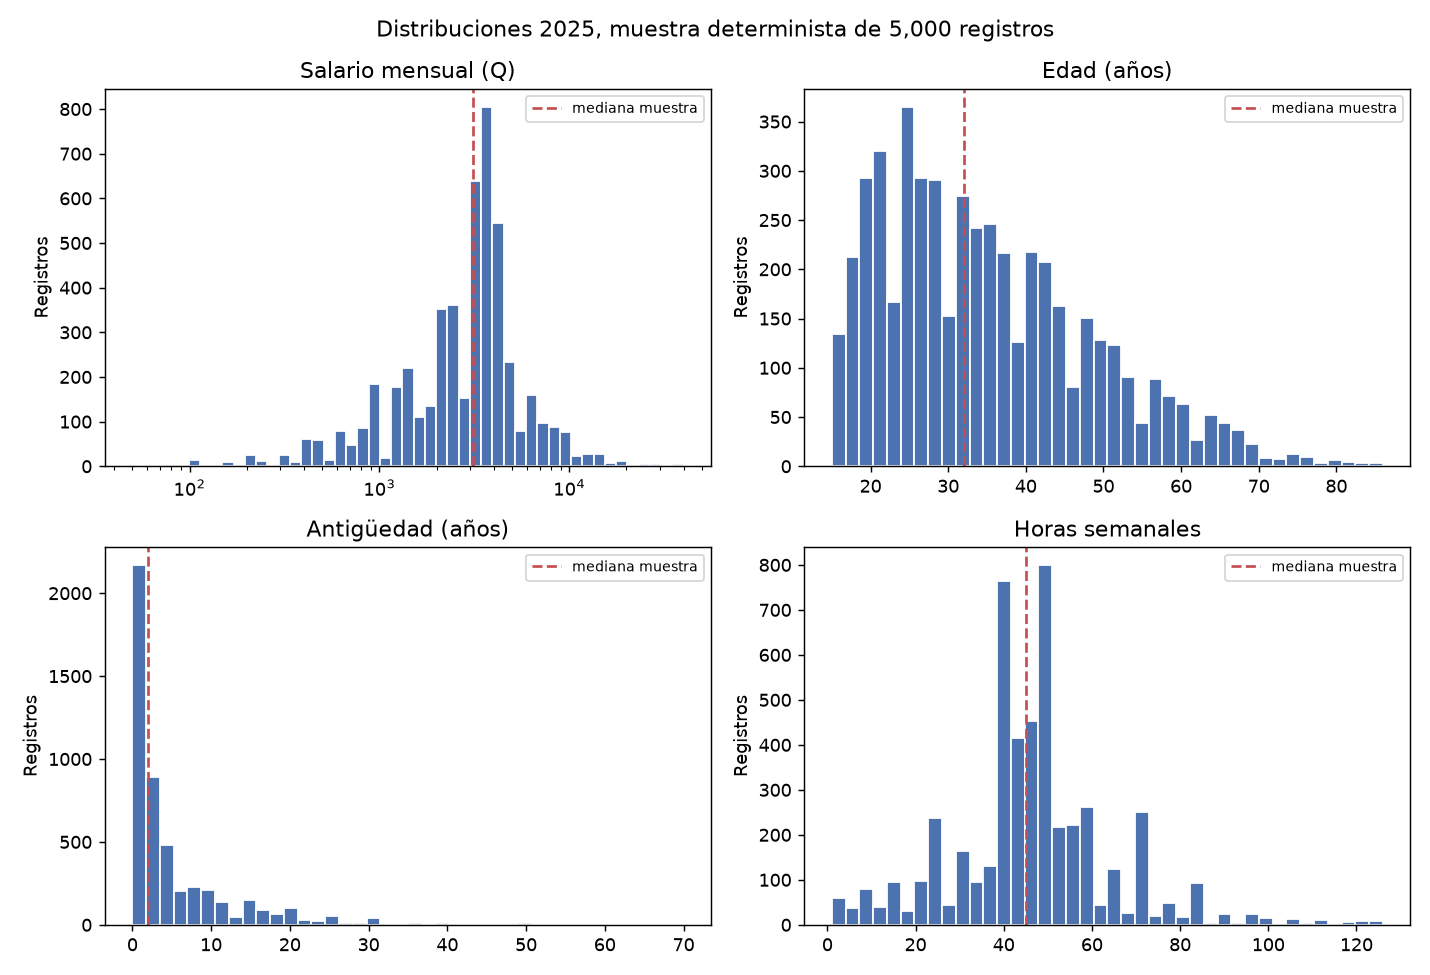

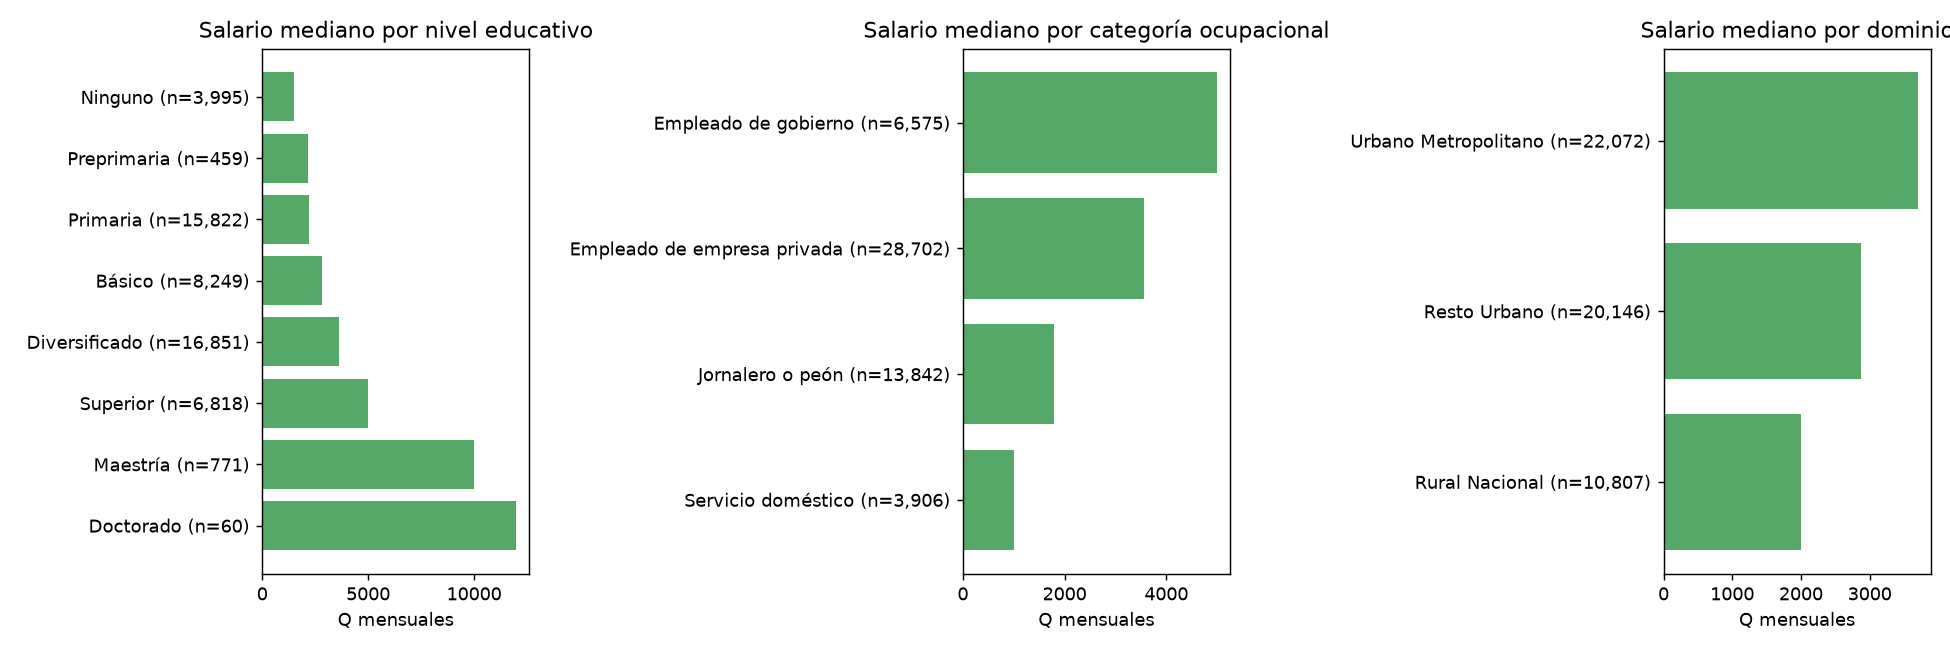

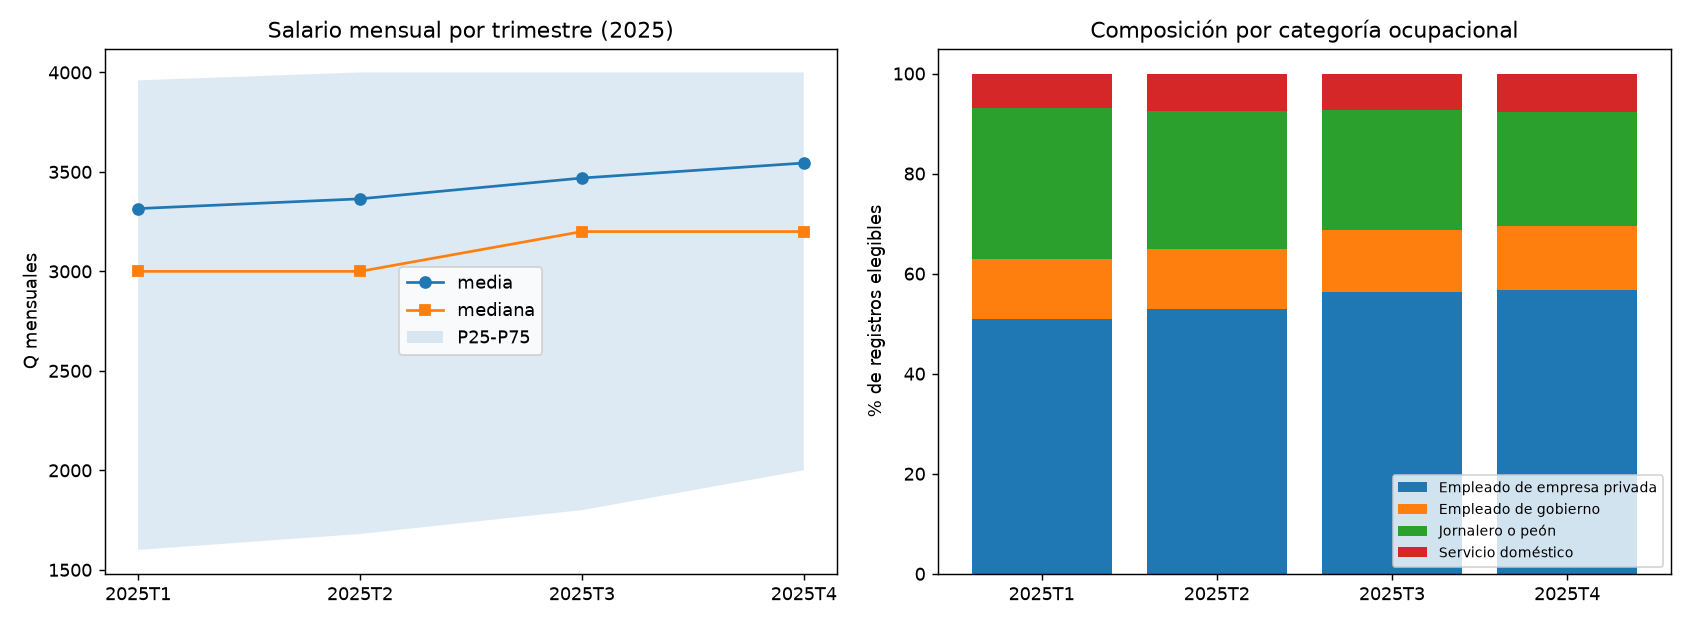

In [20]:
figure("eda/figures/distribuciones_2025.png")
figure("eda/figures/salario_mediano_por_categoria.png")
figure("eda/figures/evolucion_trimestral_2025.png")

**Lectura de las figuras anteriores.**

- **Histograma del salario (`distribuciones_2025.png`):** el eje horizontal está en **escala logarítmica** (marcas 10², 10³ y 10⁴, con 50 intervalos de ancho logarítmico). Solo el dibujo usa la muestra determinista de 5,000 registros; las estadísticas provienen de los 53,025.
  - En escala logarítmica, la mayor concentración está entre Q2,000 y Q5,000, con el pico junto a la mediana de Q3,000. Hay una cola hacia salarios muy bajos (Q100–Q1,000), coherente con la asimetría negativa del logaritmo (−0.85).
  - En quetzales, en cambio, la cola es hacia la derecha (asimetría 6.00, máximo Q99,000).
  - La escala logarítmica solo se usa para visualizar: **el modelado conserva `salario_mensual` en quetzales originales**, sin transformación.
- **Otros paneles:** la edad se concentra entre 20 y 30 años con cola hacia edades mayores. La antigüedad se acumula cerca de 0–2 años y la cola larga llega a 70. Las horas tienen picos en 40 y 48 horas.
- **Medianas por categoría (`salario_mediano_por_categoria.png`):** las barras reproducen gráficamente la tabla anterior. Crecen con la educación (de Q1,500 a Q12,000) y ordenan las categorías ocupacionales de gobierno (Q5,000) a servicio doméstico (Q1,000). Cada etiqueta incluye el tamaño del grupo.

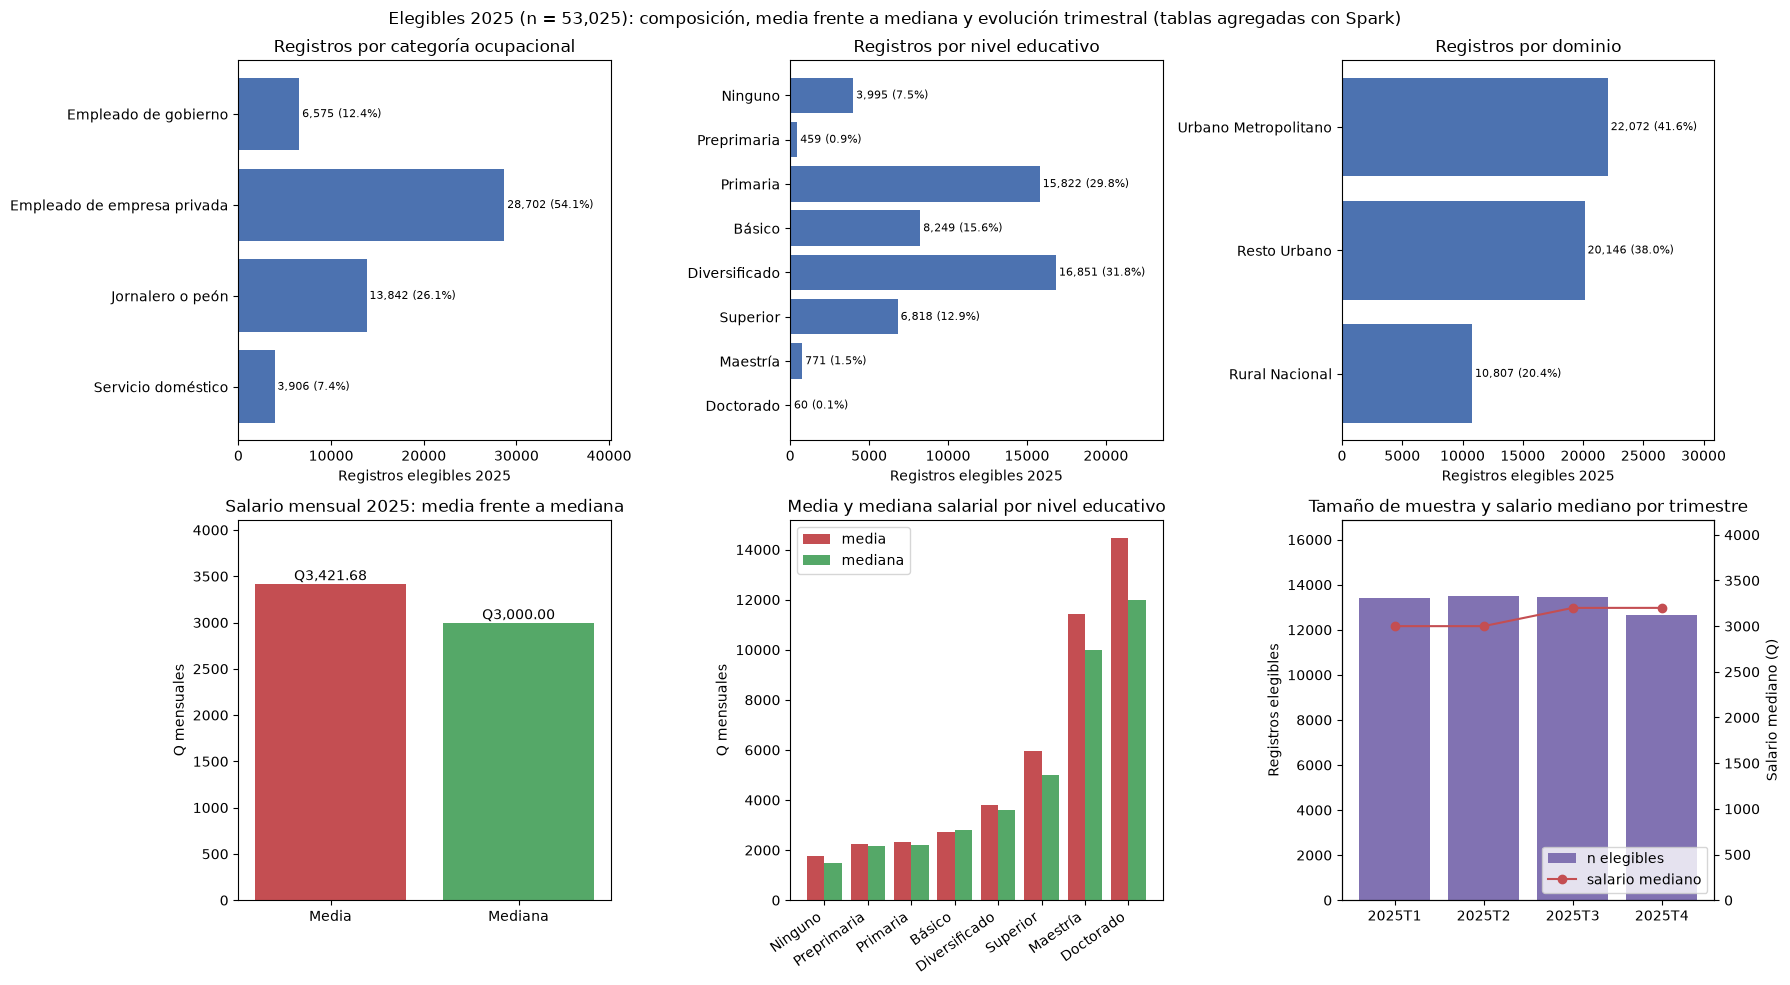

In [21]:
import matplotlib.pyplot as plt

category_tables = load("eda/categorias_2025.json")["tablas"]
salary_summary = next(item for item in descriptives["descriptivos"] if item["variable"] == "salario_mensual")
quarterly_salary = quarterly[quarterly["variable"] == "salario_mensual"].set_index("periodo_archivo")
complementary_path = OUT / "eda" / "figures" / "descriptivos_complementarios_2025.png"

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
titles = {
    "categoria_ocupacional": "Registros por categoría ocupacional",
    "nivel_educativo": "Registros por nivel educativo",
    "dominio": "Registros por dominio",
}
for axis, (column, title) in zip(axes[0], titles.items()):
    table = pd.DataFrame(category_tables[column])
    bars = axis.barh(table["etiqueta"], table["n"], color="#4C72B0")
    axis.bar_label(bars, labels=[f"{n:,} ({share:.1f}%)" for n, share in zip(table["n"], table["porcentaje"])], fontsize=8, padding=2)
    axis.invert_yaxis()
    axis.set_xlim(0, table["n"].max() * 1.4)
    axis.set_title(title)
    axis.set_xlabel("Registros elegibles 2025")

axis = axes[1][0]
values = [salary_summary["media"], salary_summary["mediana"]]
bars = axis.bar(["Media", "Mediana"], values, color=["#C44E52", "#55A868"])
axis.bar_label(bars, labels=[f"Q{value:,.2f}" for value in values])
axis.set_ylim(0, max(values) * 1.2)
axis.set_title("Salario mensual 2025: media frente a mediana")
axis.set_ylabel("Q mensuales")

axis = axes[1][1]
education = pd.DataFrame(category_tables["nivel_educativo"])
positions = list(range(len(education)))
axis.bar([position - 0.2 for position in positions], education["salario_media"], width=0.4, label="media", color="#C44E52")
axis.bar([position + 0.2 for position in positions], education["salario_mediana"], width=0.4, label="mediana", color="#55A868")
axis.set_xticks(positions, education["etiqueta"], rotation=35, ha="right")
axis.set_title("Media y mediana salarial por nivel educativo")
axis.set_ylabel("Q mensuales")
axis.legend()

axis = axes[1][2]
axis.bar(quarterly_salary.index, quarterly_salary["n"], color="#8172B2", label="n elegibles")
axis.set_ylim(0, quarterly_salary["n"].max() * 1.25)
axis.set_ylabel("Registros elegibles")
twin = axis.twinx()
twin.plot(quarterly_salary.index, quarterly_salary["mediana"], color="#C44E52", marker="o", label="salario mediano")
twin.set_ylim(0, quarterly_salary["mediana"].max() * 1.3)
twin.set_ylabel("Salario mediano (Q)")
axis.set_title("Tamaño de muestra y salario mediano por trimestre")
bar_handles, bar_labels = axis.get_legend_handles_labels()
line_handles, line_labels = twin.get_legend_handles_labels()
axis.legend(bar_handles + line_handles, bar_labels + line_labels, loc="lower right")

fig.suptitle("Elegibles 2025 (n = 53,025): composición, media frente a mediana y evolución trimestral (tablas agregadas con Spark)")
fig.tight_layout()
complementary_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(complementary_path, dpi=130)
plt.show()

**Interpretación de la figura complementaria (`eda/figures/descriptivos_complementarios_2025.png`).**

- **Categorías ocupacionales:** dominan los empleados de empresa privada, con 28,702 registros (54.1 %). Siguen los jornaleros o peones (13,842; 26.1 %), el empleo de gobierno (6,575; 12.4 %) y el servicio doméstico (3,906; 7.4 %).
- **Niveles educativos:** Diversificado (16,851; 31.8 %) y Primaria (15,822; 29.8 %) concentran seis de cada diez registros. Siguen Básico (8,249; 15.6 %), Superior (6,818; 12.9 %) y Ninguno (3,995; 7.5 %). Maestría (771; 1.5 %), Preprimaria (459; 0.9 %) y Doctorado (60; 0.1 %) son grupos pequeños.
- **Dominios:** Urbano Metropolitano tiene 22,072 registros (41.6 %), Resto Urbano 20,146 (38.0 %) y Rural Nacional 10,807 (20.4 %).
- **Asimetría y media frente a mediana:** la media (Q3,421.68) supera a la mediana (Q3,000.00) en Q421.68, un 14.1 %. Es la huella de la asimetría positiva (6.00): unos pocos salarios muy altos elevan el promedio sin mover el valor central. La brecha aparece en casi todos los niveles educativos y crece en los niveles altos. La excepción es Básico, con media Q2,730 menor que su mediana Q2,800:

  | Nivel | Media | Mediana |
  |---|---:|---:|
  | Ninguno | Q1,767 | Q1,500 |
  | Superior | Q5,965 | Q5,000 |
  | Maestría | Q11,409 | Q10,000 |
  | Doctorado | Q14,452 | Q12,000 |

- **Medianas por educación y ocupación:** la mediana sube de Q1,500 (Ninguno) a Q2,200 (Primaria), Q3,600 (Diversificado), Q5,000 (Superior) y Q10,000 (Maestría). Entre categorías va de Q5,000 (gobierno) a Q3,567.50 (empresa privada), Q1,800 (jornalero o peón) y Q1,000 (servicio doméstico).
- **Cambios entre trimestres:** el tamaño de la muestra analítica fue 13,419 (T1), 13,492 (T2, +73), 13,450 (T3, −42) y 12,664 (T4, −786, 5.8 % menos que T3). La mediana se mantuvo en Q3,000 en T1 y T2 y subió a Q3,200 en T3 y T4. T4 aporta menos registros y un nivel salarial algo mayor, lo que conviene recordar al usarlo como validación temporal.

## Ejercicio 3. Correlación de Pearson con Spark

La matriz se obtuvo con `VectorAssembler` y `Correlation.corr(method="pearson")` sobre los 53,025 elegibles de 2025.

In [22]:
show_code("pearson_matrix")

**`lab7_final.py`, líneas 1379–1386: `pearson_matrix`**

```python
def pearson_matrix(frame) -> list[list[float]]:
    from pyspark.ml.feature import VectorAssembler
    from pyspark.ml.stat import Correlation

    assembler = VectorAssembler(inputCols=list(NUMERIC_VARIABLES), outputCol="vector_correlacion")
    vectors = assembler.transform(frame.select(*NUMERIC_VARIABLES)).select("vector_correlacion")
    matrix = Correlation.corr(vectors, "vector_correlacion", "pearson").first()[0].toArray()
    return [[float(value) for value in row] for row in matrix]
```

El código ensambla las cuatro variables numéricas en un vector con `VectorAssembler`. Luego llama a `Correlation.corr(vectores, "vector_correlacion", "pearson")` de `pyspark.ml.stat` sobre los 53,025 elegibles de 2025. La matriz resultante se guardó en JSON y se muestra a continuación con sus etiquetas.

In [23]:
correlation = load("eda/correlacion_pearson_2025.json")
pd.DataFrame(correlation["matriz"], index=correlation["variables"], columns=correlation["variables"])

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.0000,0.1472,0.1796,0.0757
edad,0.1472,1.0000,0.4867,-0.1054
antiguedad,0.1796,0.4867,1.0000,-0.0623
horas_semanales,0.0757,-0.1054,-0.0623,1.0000


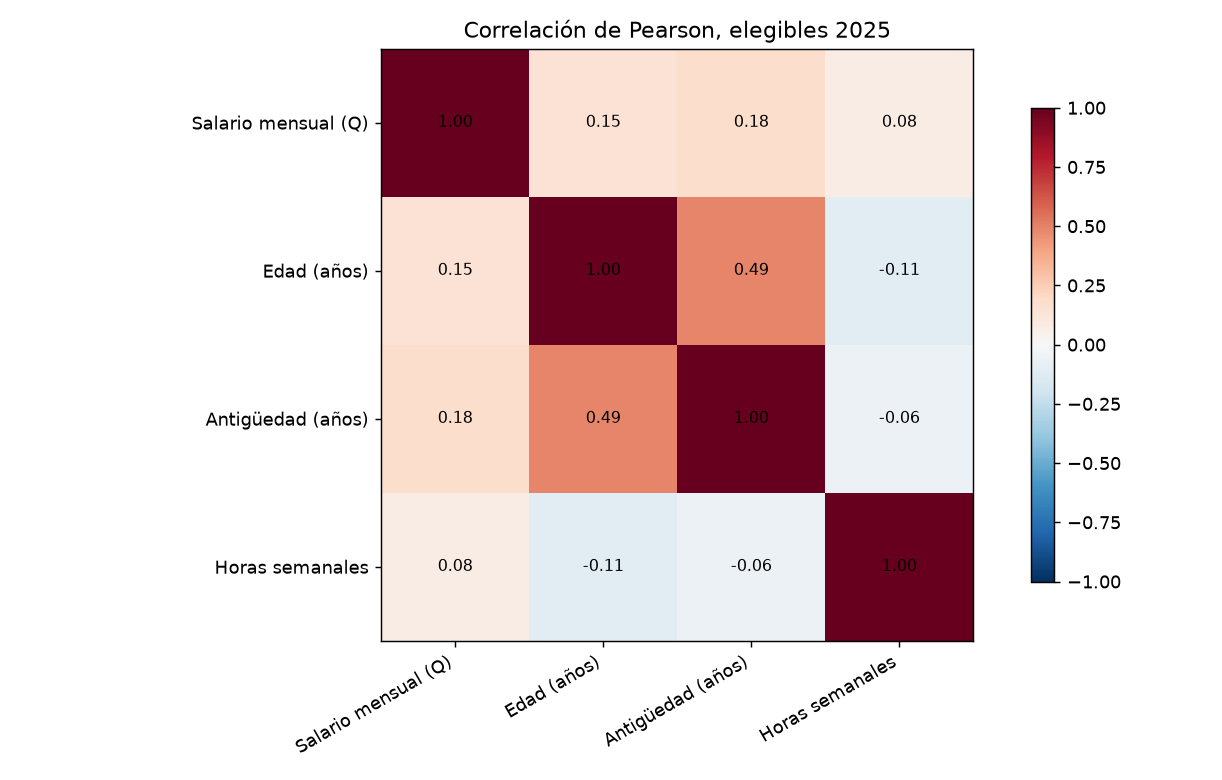

In [24]:
figure("eda/figures/correlacion_pearson_2025.png")

Las correlaciones lineales con el salario son débiles:

| Variable | r con el salario |
|---|---:|
| Antigüedad | 0.180 |
| Edad | 0.147 |
| Horas semanales | 0.076 |

La relación más fuerte es entre edad y antigüedad (r = 0.487), algo esperable porque la antigüedad crece con la edad. Horas y edad se relacionan débil y negativamente (r = −0.105). Pearson solo mide asociación lineal y es sensible a la cola salarial extrema. Una correlación baja no descarta relaciones no lineales ni diferencias entre categorías, que sí aparecen en las medianas por educación y categoría ocupacional.

## Ejercicio 4. KMeans estandarizado (K = 2..5)

- **Ajuste:** KMeans se ajustó con edad, antigüedad, horas semanales y nivel educativo. El nivel educativo se trató como ordinal 0–7.
- **Escalado:** todas las variables se estandarizaron con `StandardScaler(withMean=True, withStd=True)`.
- **Salario excluido:** el salario quedó fuera del ajuste para perfilar condiciones personales y laborales; después se usó solo para caracterizar cada cluster.
- **Parámetros:** semilla 3066 y K = 2, 3, 4 y 5.
- **Criterio:** gana la mayor silueta; WSSSE es evidencia complementaria de codo.

**¿Vale la pena incluir el salario en KMeans? No, para el objetivo de este inciso.**

1. **Asimetría extrema.** El salario tiene asimetría 6.00 y un máximo de Q99,000. Tras estandarizar, ese salario quedaría a (99,000 − 3,421.68) / 2,902.11 ≈ 32.9 desviaciones de la media. La edad máxima (89 años) queda a (89 − 35.19) / 13.52 ≈ 4.0 desviaciones. Los pocos salarios extremos dominarían las distancias euclidianas y el algoritmo tendería a aislar esos casos en lugar de describir perfiles.
2. **Objetivo del inciso.** Se busca perfilar condiciones personales y laborales (edad, antigüedad, jornada y escolaridad). Incluir el salario mezclaría el resultado con la descripción.
3. **Uso posterior.** El salario se reserva para **caracterizar** cada cluster una vez formado. Así puede compararse entre perfiles sin haber influido en su construcción.

**Nivel educativo como aproximación ordinal.** Los códigos 0–7 se usan como número porque los niveles tienen un orden natural. Esto supone que la distancia entre niveles consecutivos es igual; por ejemplo, Primaria→Básico pesa lo mismo que Superior→Maestría. Es una simplificación: una codificación one-hot evitaría ese supuesto, a costa de más dimensiones y distancias menos interpretables.

El código real de estandarización, KMeans, silueta y WSSSE es el siguiente:

In [25]:
show_code("cluster_input", "fit_standardizer", "compare_kmeans", "select_k")

**`lab7_final.py`, líneas 1389–1392: `cluster_input`**

```python
def cluster_input(frame):
    from pyspark.sql import functions as F

    return frame.withColumn("nivel_educativo_ordinal", F.col("nivel_educativo").cast("double"))
```

**`lab7_final.py`, líneas 1395–1401: `fit_standardizer`**

```python
def fit_standardizer(frame):
    from pyspark.ml import Pipeline
    from pyspark.ml.feature import StandardScaler, VectorAssembler

    assembler = VectorAssembler(inputCols=list(CLUSTER_FEATURES), outputCol="features_raw")
    scaler = StandardScaler(inputCol="features_raw", outputCol="features_std", withMean=True, withStd=True)
    return Pipeline(stages=[assembler, scaler]).fit(frame)
```

**`lab7_final.py`, líneas 1404–1433: `compare_kmeans`**

```python
def compare_kmeans(scaled) -> tuple[list[dict[str, Any]], dict[int, Any]]:
    from pyspark.ml.clustering import KMeans
    from pyspark.ml.evaluation import ClusteringEvaluator

    evaluator = ClusteringEvaluator(
        featuresCol="features_std", predictionCol="cluster", metricName="silhouette", distanceMeasure="squaredEuclidean"
    )
    results = []
    models = {}
    for k in K_RANGE:
        started = time.perf_counter()
        model = KMeans(
            featuresCol="features_std", predictionCol="cluster", k=k, seed=SEED, maxIter=KMEANS_MAX_ITER, initMode="k-means||"
        ).fit(scaled)
        silhouette = evaluator.evaluate(model.transform(scaled))
        results.append(
            {
                "k": k,
                "silueta": float(silhouette),
                "wssse": float(model.summary.trainingCost),
                "tamanos": [int(size) for size in model.summary.clusterSizes],
                "iteraciones": int(model.summary.numIter),
                "segundos": round(time.perf_counter() - started, 1),
            }
        )
        models[k] = model
        print(f"  K={k}: silueta={silhouette:.4f} WSSSE={model.summary.trainingCost:,.1f}")
    for previous, current in zip(results, results[1:]):
        current["reduccion_wssse_pct"] = 100.0 * (previous["wssse"] - current["wssse"]) / previous["wssse"]
    return results, models
```

**`lab7_final.py`, líneas 1436–1437: `select_k`**

```python
def select_k(results: list[dict[str, Any]]) -> int:
    return max(results, key=lambda item: (round(item["silueta"], 6), -item["k"]))["k"]
```

Pasos del código:

1. `VectorAssembler` y `StandardScaler(withMean=True, withStd=True)` se ajustan en un `Pipeline` sobre los 53,025 registros.
2. Para cada K de 2 a 5 se entrena `KMeans(seed=3066, maxIter=100, initMode="k-means||")`.
3. La **silueta** se mide con `ClusteringEvaluator(metricName="silhouette", distanceMeasure="squaredEuclidean")`.
4. La **WSSSE** se toma de `model.summary.trainingCost`.
5. `select_k` elige la mayor silueta; en caso de empate, el K menor.

In [26]:
kmeans = load("eda/kmeans_seleccion.json")
pd.DataFrame(kmeans["resultados"]).set_index("k")[["silueta", "wssse", "reduccion_wssse_pct", "tamanos", "iteraciones"]]

,silueta,wssse,reduccion_wssse_pct,tamanos,iteraciones
k,,,,,
2,0.4666,"158,529.2727",NaN,"[37182, 15843]",27
3,0.3686,"131,633.2571",16.9660,"[26078, 8412, 18535]",81
4,0.4046,"109,241.5361",17.0107,"[25456, 11509, 7146, 8914]",24
5,0.3678,"95,220.4603",12.8349,"[11546, 18953, 4614, 10455, 7457]",27


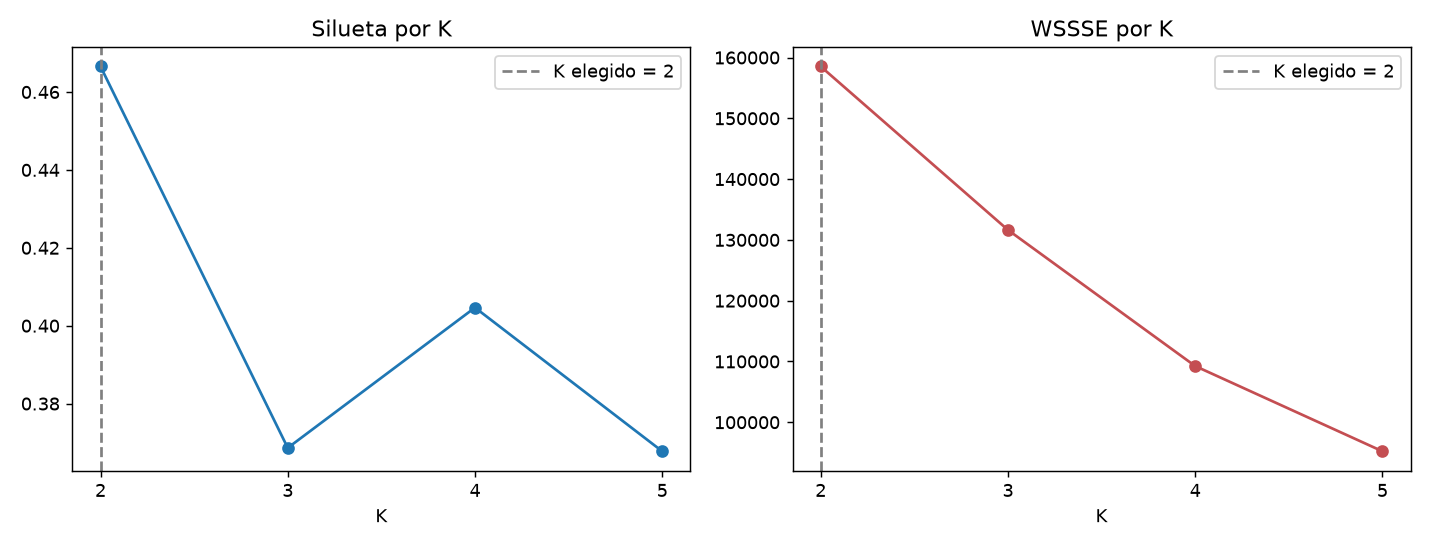

In [27]:
figure("eda/figures/kmeans_silueta_wssse.png")

La mayor silueta corresponde a **K = 2 (0.4666)**. Le siguen K = 4 (0.4046), K = 3 (0.3686) y K = 5 (0.3678).

WSSSE baja de 158,529 (K = 2) a 131,633, 109,242 y 95,220. Las reducciones son de 17.0 %, 17.0 % y 12.8 %, sin un codo marcado. Como la silueta favorece claramente a K = 2 y la WSSSE no muestra un quiebre que justifique más grupos, se eligió K = 2.

K = 2 es el mejor valor **entre los K probados**, no un óptimo universal. No está en el límite superior del rango ensayado.

In [28]:
profiles = load("eda/clusters_perfiles.json")["perfiles"]
rows = []
for profile in profiles:
    row = {"cluster": profile["cluster"], "n": profile["n"], "porcentaje": profile["porcentaje"]}
    for variable in ("edad", "antiguedad", "horas_semanales", "salario_mensual"):
        row[f"{variable}_media"] = profile["estadisticas"][variable]["media"]
        row[f"{variable}_mediana"] = profile["estadisticas"][variable]["mediana"]
    for column in ("nivel_educativo", "categoria_ocupacional", "dominio"):
        top = profile["composicion"][column][0]
        row[f"{column}_modal"] = f"{top['etiqueta']} ({top['porcentaje']:.1f}%)"
    rows.append(row)
pd.DataFrame(rows).set_index("cluster").T

cluster,0,1
n,37182,15843
porcentaje,70.1216,29.8784
edad_media,28.5194,50.8375
edad_mediana,28.0000,50.0000
antiguedad_media,2.5174,12.6968
antiguedad_mediana,1.5000,12.0000
horas_semanales_media,48.3270,41.5677
horas_semanales_mediana,46.0000,40.0000
salario_mensual_media,"3,296.0215","3,716.6025"
salario_mensual_mediana,"3,000.0000","3,000.0000"


In [29]:
for profile in sorted(profiles, key=lambda item: item["cluster"]):
    print(profile["descripcion"], end="\n\n")

Cluster 0: 37,182 registros (70.1%). Edad mediana 28 años (global 33), antigüedad mediana 1.5 años (global 2.0) y 46 horas semanales medianas (global 45). Nivel educativo más frecuente: Diversificado (37.2%); categoría más frecuente: Empleado de empresa privada (59.8%); dominio más frecuente: Urbano Metropolitano (41.0%). Salario mensual mediano Q3,000 y medio Q3,296, 1.00 veces la mediana global; el salario no participó en el ajuste del cluster.

Cluster 1: 15,843 registros (29.9%). Edad mediana 50 años (global 33), antigüedad mediana 12.0 años (global 2.0) y 40 horas semanales medianas (global 45). Nivel educativo más frecuente: Primaria (36.9%); categoría más frecuente: Empleado de empresa privada (40.8%); dominio más frecuente: Urbano Metropolitano (43.1%). Salario mensual mediano Q3,000 y medio Q3,717, 1.00 veces la mediana global; el salario no participó en el ajuste del cluster.



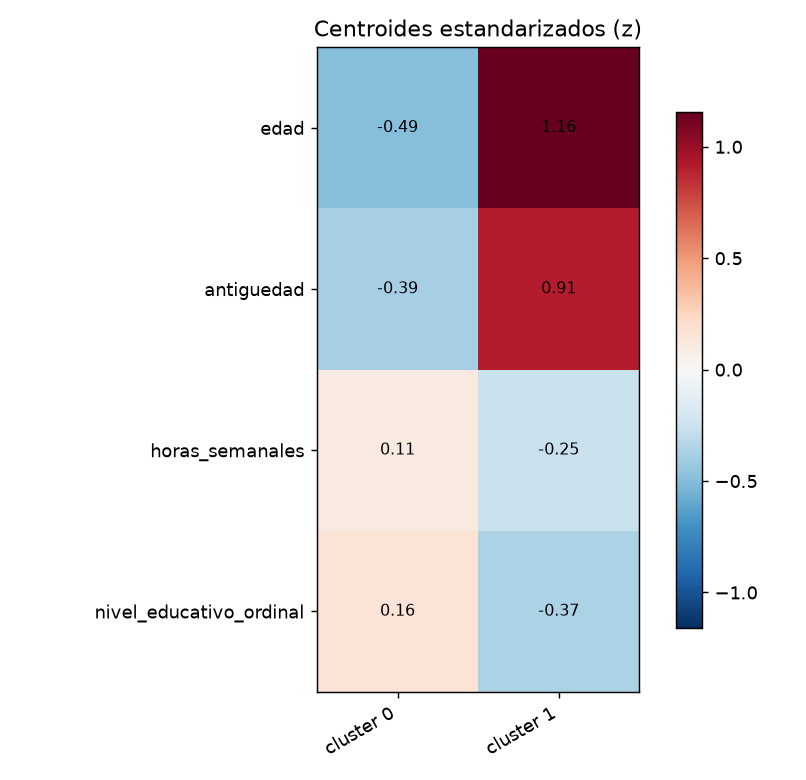

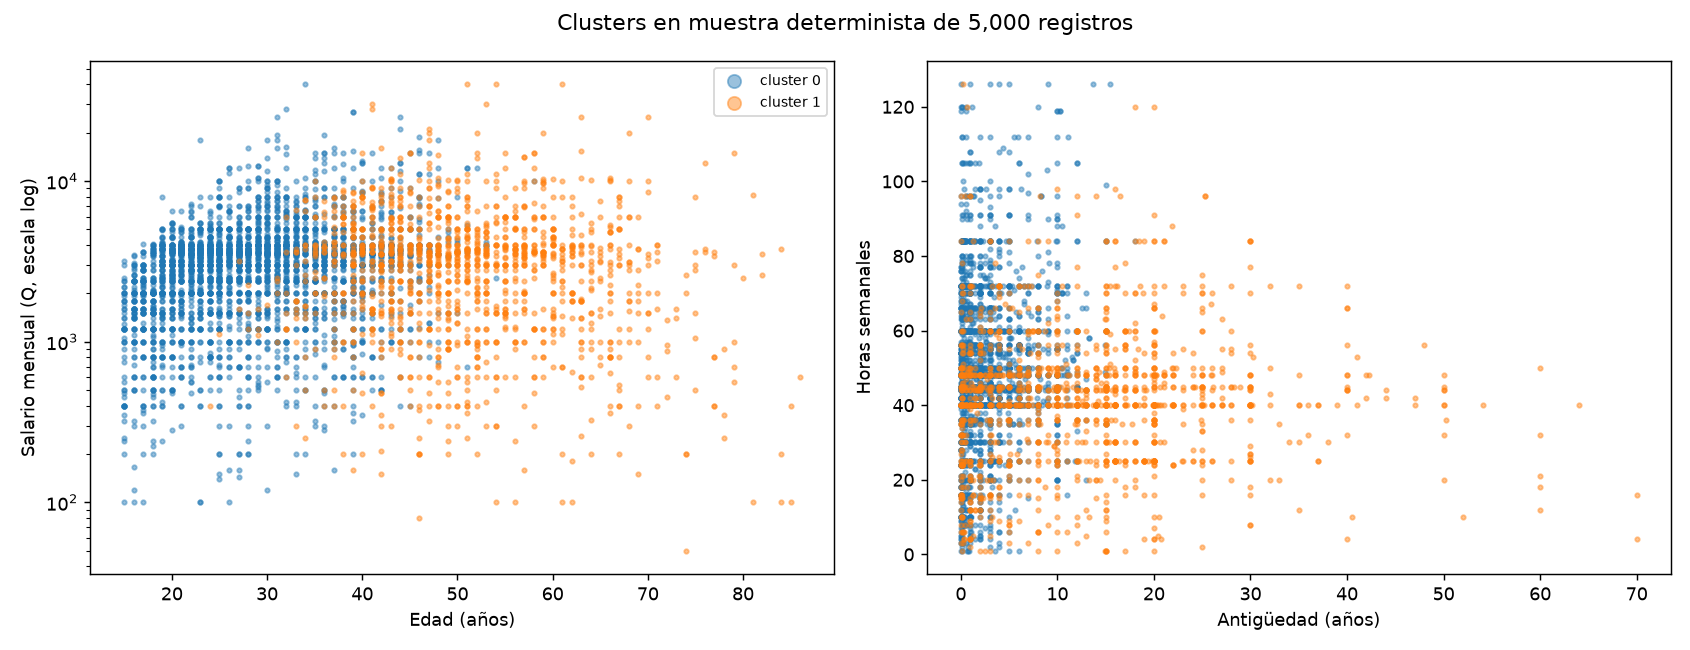

In [30]:
figure("eda/figures/kmeans_centroides_estandarizados.png")
figure("eda/figures/kmeans_clusters_muestra.png")

**Cluster 0: trabajadores jóvenes con poca antigüedad y más escolaridad** (37,182 registros, 70.1 %)

- Edad mediana de 28 años, antigüedad mediana de 1.5 años y 46 horas semanales medianas.
- Nivel educativo modal: Diversificado (37.2 %).
- Predominan los empleados de empresa privada (59.8 %).

**Cluster 1: trabajadores mayores con trayectorias largas y menor escolaridad** (15,843 registros, 29.9 %)

- Edad mediana de 50 años, antigüedad mediana de 12.0 años y 40 horas semanales medianas.
- Nivel educativo modal: Primaria (36.9 %).
- También predominan los empleados de empresa privada, en menor proporción (40.8 %).

En ambos clusters el dominio más frecuente es Urbano Metropolitano (41.0 % y 43.1 %).

Al caracterizarlos con el salario, que no participó en el ajuste, ambos clusters tienen la misma mediana (Q3,000). La media es mayor en el cluster 1 (Q3,717 frente a Q3,296), lo que indica una cola alta más pesada entre trabajadores con más antigüedad.

La segmentación separa sobre todo etapas del ciclo laboral (edad y antigüedad), no niveles salariales. Una silueta de 0.47 indica una separación moderada, no grupos nítidamente aislados.

**Lectura de las figuras de clusters.**

- **Centroides estandarizados (`kmeans_centroides_estandarizados.png`):**
  - El cluster 0 tiene valores *z* de −0.49 en edad, −0.39 en antigüedad, +0.11 en horas y +0.16 en educación. En unidades originales: 28.5 años, 2.5 años de antigüedad, 48.3 horas y nivel educativo 3.3.
  - El cluster 1 tiene +1.16 en edad, +0.91 en antigüedad, −0.25 en horas y −0.37 en educación. En unidades originales: 50.8 años, 12.7 años de antigüedad, 41.6 horas y nivel educativo 2.6.
  - La separación la producen sobre todo edad y antigüedad.
- **Dispersión (`kmeans_clusters_muestra.png`, muestra de 5,000):**
  - Panel izquierdo (edad frente a salario, eje vertical logarítmico): el cluster 0 ocupa las edades de 15 a cerca de 40 años (P25–P75: 22–34) y el cluster 1 de cerca de 40 en adelante (P25–P75: 43–58), con traslape alrededor de los 40. Ambos clusters recorren todo el rango salarial, de Q100 a más de Q10,000: **el salario no separa los grupos**, coherente con medianas iguales (Q3,000).
  - Panel derecho (antigüedad frente a horas): el cluster 0 se concentra en antigüedades de 0 a 10 años y el cluster 1 se extiende hasta 70 años de antigüedad. Las horas se traslapan casi por completo entre 25 y 60, con acumulación en 40–48.

## Ejercicio 5. Regresión lineal con validación temporal

**Separación temporal sin fuga de información**

- Entrenamiento: 2025T1–T3 (**40,361** filas). Validación: 2025T4 (**12,664** filas). No se usó `randomSplit`, validación cruzada ni datos de 2026.
- `StringIndexer`, `OneHotEncoder` y `StandardScaler` están dentro de cada `Pipeline` y se ajustan solo con T1–T3. T4 únicamente se transforma y se evalúa.
- El baseline predice la media salarial de T1–T3 (Q3,383.12), no la de T4.

**Especificación**

- Predictores: edad, antigüedad y horas semanales (numéricos); nivel educativo, categoría ocupacional y dominio (categóricos).
- Objetivo: `salario_mensual`, sin recorte ni transformación.
- Una sola estandarización explícita: `StandardScaler` sobre el vector ensamblado y `LinearRegression(standardization=False)`.
- Se probaron cuatro valores de `regParam` (0, 10, 100, 1000, penalización ridge). Spark expresa `regParam` en unidades del objetivo; la penalización efectiva es `regParam` dividido por la desviación estándar del salario.

In [31]:
show_code("temporal_partitions", "partition_checks", "categorical_stages", "assembled_inputs", "linear_pipeline", "regression_metrics", "fit_candidates")

**`lab7_final.py`, líneas 1978–1988: `temporal_partitions`**

```python
def temporal_partitions(spark, checks: CheckLog):
    from pyspark.sql import functions as F

    frame = spark.read.parquet(str(ELIGIBLE_2025))
    foreign = frame.filter((F.col("anio_archivo") != 2025) | F.col("periodo_archivo").startswith("2026")).count()
    checks.require(foreign == 0, f"{foreign} filas ajenas a 2025 en {relative(ELIGIBLE_2025)}")
    columns = ["id_registro", "periodo_archivo", "fila_origen", TARGET, *NUMERIC_PREDICTORS, *CATEGORICAL_PREDICTORS]
    selected = frame.select(*columns)
    train = selected.filter(F.col("periodo_archivo").isin(*TRAIN_PERIODS))
    validation = selected.filter(F.col("periodo_archivo") == VALIDATION_PERIOD)
    return train, validation
```

**`lab7_final.py`, líneas 1991–2006: `partition_checks`**

```python
def partition_checks(train, validation, checks: CheckLog) -> tuple[int, int]:
    from pyspark.sql import functions as F

    train_n = train.count()
    validation_n = validation.count()
    checks.require(train_n == TRAIN_ROWS, f"entrenamiento {train_n} != {TRAIN_ROWS}")
    checks.require(validation_n == VALIDATION_ROWS, f"validacion {validation_n} != {VALIDATION_ROWS}")
    checks.require(train.select("id_registro").distinct().count() == train_n, "entrenamiento: id_registro duplicado")
    checks.require(validation.select("id_registro").distinct().count() == validation_n, "validacion: id_registro duplicado")
    overlap = train.select("id_registro").intersect(validation.select("id_registro")).count()
    checks.require(overlap == 0, f"{overlap} id_registro compartidos entre entrenamiento y validacion")
    nulls = train.unionByName(validation).agg(
        *[F.sum(F.when(F.col(column).isNull(), 1).otherwise(0)).alias(column) for column in (TARGET, *PREDICTORS)]
    ).first().asDict()
    checks.require(all((value or 0) == 0 for value in nulls.values()), f"nulos en predictores u objetivo {nulls}")
    return train_n, validation_n
```

**`lab7_final.py`, líneas 2009–2022: `categorical_stages`**

```python
def categorical_stages() -> list[Any]:
    from pyspark.ml.feature import OneHotEncoder, StringIndexer

    indexers = [
        StringIndexer(inputCol=column, outputCol=f"{column}_idx", handleInvalid="keep", stringOrderType="alphabetAsc")
        for column in CATEGORICAL_PREDICTORS
    ]
    encoder = OneHotEncoder(
        inputCols=[f"{column}_idx" for column in CATEGORICAL_PREDICTORS],
        outputCols=[f"{column}_ohe" for column in CATEGORICAL_PREDICTORS],
        handleInvalid="keep",
        dropLast=True,
    )
    return [*indexers, encoder]
```

**`lab7_final.py`, líneas 2025–2026: `assembled_inputs`**

```python
def assembled_inputs() -> list[str]:
    return [*NUMERIC_PREDICTORS, *[f"{column}_ohe" for column in CATEGORICAL_PREDICTORS]]
```

**`lab7_final.py`, líneas 2029–2051: `linear_pipeline`**

```python
def linear_pipeline(config: dict[str, Any]):
    from pyspark.ml import Pipeline
    from pyspark.ml.feature import StandardScaler, VectorAssembler
    from pyspark.ml.regression import LinearRegression

    return Pipeline(
        stages=[
            *categorical_stages(),
            VectorAssembler(inputCols=assembled_inputs(), outputCol="features_raw"),
            StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True),
            LinearRegression(
                featuresCol="features",
                labelCol=TARGET,
                predictionCol="prediccion",
                regParam=config["regParam"],
                elasticNetParam=config["elasticNetParam"],
                standardization=False,
                fitIntercept=True,
                maxIter=LR_MAX_ITER,
                solver="l-bfgs",
            ),
        ]
    )
```

**`lab7_final.py`, líneas 2078–2086: `regression_metrics`**

```python
def regression_metrics(frame, prediction_column: str) -> dict[str, float]:
    from pyspark.ml.evaluation import RegressionEvaluator

    return {
        metric: float(
            RegressionEvaluator(labelCol=TARGET, predictionCol=prediction_column, metricName=metric).evaluate(frame)
        )
        for metric in ("mae", "rmse", "r2")
    }
```

**`lab7_final.py`, líneas 2126–2150: `fit_candidates`**

```python
def fit_candidates(algorithm: str, configs: list[dict[str, Any]], builder, train, validation) -> tuple[list[dict[str, Any]], Any]:
    rows = []
    best_model = None
    best_rmse = math.inf
    for config in configs:
        started = time.perf_counter()
        model = builder(config).fit(train)
        metrics = regression_metrics(model.transform(validation), "prediccion")
        row = {
            "algoritmo": algorithm,
            "config_id": config["config_id"],
            "parametros": {key: value for key, value in config.items() if key != "config_id"},
            **metrics,
            "n_validacion": VALIDATION_ROWS,
            "segundos": round(time.perf_counter() - started, 1),
            "seleccionado": False,
        }
        rows.append(row)
        print(f"  {config['config_id']}: MAE={metrics['mae']:,.2f} RMSE={metrics['rmse']:,.2f} R2={metrics['r2']:.4f}")
        if metrics["rmse"] < best_rmse:
            best_rmse = metrics["rmse"]
            best_model = model
    selected = min(rows, key=lambda item: item["rmse"])
    selected["seleccionado"] = True
    return rows, best_model
```

Pasos del código:

1. `temporal_partitions` separa T1–T3 (entrenamiento) y T4 (validación) por `periodo_archivo`. Solo lee `eligible_2025.parquet`, así que 2026 no interviene.
2. `categorical_stages` crea un `StringIndexer(handleInvalid="keep")` por variable categórica y un `OneHotEncoder(handleInvalid="keep")`.
3. `linear_pipeline` encadena esas etapas con `VectorAssembler`, `StandardScaler` y `LinearRegression(standardization=False)`.
4. En `fit_candidates`, `builder(config).fit(train)` ajusta **todo** el pipeline exclusivamente con T1–T3. `model.transform(validation)` solo aplica lo aprendido a T4.
5. `regression_metrics` calcula MAE, RMSE y R² con `RegressionEvaluator`.

In [32]:
validation_configs = load("models/validation_configs.json")
pd.Series(validation_configs["particion"], name="valor").to_frame()

,valor
entrenamiento,"[2025T1, 2025T2, 2025T3]"
validacion,2025T4
n_entrenamiento,40361
n_validacion,12664
datos_2026_usados,False
randomSplit,False
cross_validation,False


In [33]:
validation_metrics = load("models/validation_metrics.json")
validation_table = pd.DataFrame([validation_metrics["baseline"], *validation_metrics["candidatos"]]).set_index("config_id")[
    ["algoritmo", "mae", "rmse", "r2", "n_validacion", "seleccionado"]
]
validation_table[validation_table["algoritmo"].isin(["baseline_media", "regresion_lineal"])]

,algoritmo,mae,rmse,r2,n_validacion,seleccionado
config_id,,,,,,
baseline_media_T1_T3,baseline_media,"1,672.5026","2,889.5714",-0.0031,12664,True
lr_reg_0.0,regresion_lineal,"1,210.1375","2,186.4196",0.4257,12664,True
lr_reg_10.0,regresion_lineal,"1,209.6705","2,186.5514",0.4256,12664,False
lr_reg_100.0,regresion_lineal,"1,205.9311","2,188.0623",0.4248,12664,False
lr_reg_1000.0,regresion_lineal,"1,198.0001","2,220.9586",0.4074,12664,False


In [34]:
lr_settings = validation_configs["regresion_lineal"]
lr_hyperparameters = pd.DataFrame(lr_settings["configuraciones"]).set_index("config_id")
lr_hyperparameters["estandarizacion"] = "StandardScaler(withMean=True, withStd=True)"
lr_hyperparameters["standardization_interna"] = False
lr_hyperparameters["solver"] = lr_settings["solver"]
lr_hyperparameters["maxIter"] = lr_settings["max_iter"]
lr_hyperparameters["fitIntercept"] = True
lr_hyperparameters["tol"] = "1e-06 (predeterminado de Spark)"
lr_hyperparameters["loss"] = "squaredError (predeterminado de Spark)"
lr_hyperparameters["rmse_2025T4"] = validation_table.loc[lr_hyperparameters.index, "rmse"]
lr_hyperparameters["seleccionado"] = validation_table.loc[lr_hyperparameters.index, "seleccionado"]
display(lr_hyperparameters)
pd.Series(
    {
        "preprocesamiento_categorico": validation_configs["preprocesamiento_categorico"],
        "escala_regParam": lr_settings["escala_regParam"],
        "codificacion": lr_settings["codificacion"],
    },
    name="valor",
).to_frame()

,regParam,elasticNetParam,estandarizacion,standardization_interna,solver,maxIter,fitIntercept,tol,loss,rmse_2025T4,seleccionado
config_id,,,,,,,,,,,
lr_reg_0.0,0.0000,0.0000,"StandardScaler(withMean=True, withStd=True)",False,l-bfgs,200,True,1e-06 (predeterminado de Spark),squaredError (predeterminado de Spark),"2,186.4196",True
lr_reg_10.0,10.0000,0.0000,"StandardScaler(withMean=True, withStd=True)",False,l-bfgs,200,True,1e-06 (predeterminado de Spark),squaredError (predeterminado de Spark),"2,186.5514",False
lr_reg_100.0,100.0000,0.0000,"StandardScaler(withMean=True, withStd=True)",False,l-bfgs,200,True,1e-06 (predeterminado de Spark),squaredError (predeterminado de Spark),"2,188.0623",False
lr_reg_1000.0,"1,000.0000",0.0000,"StandardScaler(withMean=True, withStd=True)",False,l-bfgs,200,True,1e-06 (predeterminado de Spark),squaredError (predeterminado de Spark),"2,220.9586",False


,valor
preprocesamiento_categorico,"StringIndexer(handleInvalid=keep, stringOrderT..."
escala_regParam,Spark expresa regParam en unidades del objetiv...
codificacion,OneHotEncoder con handleInvalid=keep conserva ...


**Resultados en 2025T4**

| Modelo | MAE | RMSE | R² |
|---|---:|---:|---:|
| Baseline (media de T1–T3) | Q1,672.50 | Q2,889.57 | −0.0031 |
| Regresión lineal `lr_reg_0.0` | Q1,210.14 | Q2,186.42 | 0.4257 |

- **Baseline:** su R² es levemente negativo porque la media de T1–T3 es menor que la de T4.
- **Selección:** con `regParam = 0` la regresión reduce el RMSE del baseline en 24.3 %. Con 10 y 100 el RMSE cambia menos de Q2 (Q2,186.55 y Q2,188.06). Con 1000 sube a Q2,220.96, aunque el MAE baja a Q1,198.00.
- **Por qué casi no influye la regularización:** hay unas veinte columnas de diseño frente a 40,361 observaciones.
- **Criterio:** la selección usa exclusivamente el menor RMSE en T4, por lo que queda `lr_reg_0.0`.
- **Colinealidad:** `OneHotEncoder(handleInvalid="keep")` conserva todas las categorías vistas más una columna de categoría no vista, colineal con el intercepto. Esto afecta la interpretación individual de coeficientes, no las predicciones ni las métricas.

## Ejercicio 6. Random Forest con las mismas particiones

- **Mismos datos y tratamiento categórico:** el mismo T1–T3/T4, `StringIndexer` y `OneHotEncoder`, sin estandarización numérica.
- **Parámetros fijos:** semilla 3066, `featureSubsetStrategy="onethird"`, `maxBins=32`.
- **Configuraciones:** tres combinaciones acotadas de `numTrees`/`maxDepth`.

In [35]:
show_code("forest_pipeline")
rf_settings = validation_configs["random_forest"]
rf_hyperparameters = pd.DataFrame(rf_settings["configuraciones"]).set_index("config_id")
rf_hyperparameters["seed"] = rf_settings["semilla"]
rf_hyperparameters["maxBins"] = rf_settings["max_bins"]
rf_hyperparameters["featureSubsetStrategy"] = rf_settings["feature_subset_strategy"]
rf_hyperparameters["subsamplingRate"] = 1.0
rf_hyperparameters["estandarizacion"] = rf_settings["estandarizacion"]
rf_hyperparameters["impurity"] = "variance (predeterminado de Spark)"
rf_hyperparameters["minInstancesPerNode"] = "1 (predeterminado de Spark)"
rf_hyperparameters["minInfoGain"] = "0.0 (predeterminado de Spark)"
rf_hyperparameters["bootstrap"] = "True (predeterminado de Spark)"
rf_hyperparameters["rmse_2025T4"] = validation_table.loc[rf_hyperparameters.index, "rmse"]
rf_hyperparameters["seleccionado"] = validation_table.loc[rf_hyperparameters.index, "seleccionado"]
rf_hyperparameters

**`lab7_final.py`, líneas 2054–2075: `forest_pipeline`**

```python
def forest_pipeline(config: dict[str, Any]):
    from pyspark.ml import Pipeline
    from pyspark.ml.feature import VectorAssembler
    from pyspark.ml.regression import RandomForestRegressor

    return Pipeline(
        stages=[
            *categorical_stages(),
            VectorAssembler(inputCols=assembled_inputs(), outputCol="features"),
            RandomForestRegressor(
                featuresCol="features",
                labelCol=TARGET,
                predictionCol="prediccion",
                numTrees=config["numTrees"],
                maxDepth=config["maxDepth"],
                maxBins=RF_MAX_BINS,
                subsamplingRate=1.0,
                featureSubsetStrategy="onethird",
                seed=SEED,
            ),
        ]
    )
```

,numTrees,maxDepth,seed,maxBins,featureSubsetStrategy,subsamplingRate,estandarizacion,impurity,minInstancesPerNode,minInfoGain,bootstrap,rmse_2025T4,seleccionado
config_id,,,,,,,,,,,,,
rf_t50_d6,50,6,3066,32,onethird,1.0000,ninguna,variance (predeterminado de Spark),1 (predeterminado de Spark),0.0 (predeterminado de Spark),True (predeterminado de Spark),"2,108.3841",False
rf_t100_d8,100,8,3066,32,onethird,1.0000,ninguna,variance (predeterminado de Spark),1 (predeterminado de Spark),0.0 (predeterminado de Spark),True (predeterminado de Spark),"2,039.6256",False
rf_t100_d10,100,10,3066,32,onethird,1.0000,ninguna,variance (predeterminado de Spark),1 (predeterminado de Spark),0.0 (predeterminado de Spark),True (predeterminado de Spark),"1,985.5950",True


El pipeline de Random Forest reutiliza `categorical_stages()`, es decir, el mismo `StringIndexer` y `OneHotEncoder`. Ensambla con `VectorAssembler` y entrena `RandomForestRegressor` **sin estandarización**, sobre las mismas particiones T1–T3/T4 y con el mismo `fit_candidates`.

La tabla documenta los valores usados:

- **Variables por configuración:** `numTrees` y `maxDepth`: 50/6, 100/8 y 100/10.
- **Fijados explícitamente en el código:** semilla 3066, `maxBins=32`, `featureSubsetStrategy="onethird"` y `subsamplingRate=1.0`.
- **Predeterminados de Spark (no se modificaron):** `impurity`, `minInstancesPerNode`, `minInfoGain` y `bootstrap`.

In [36]:
validation_table[validation_table["algoritmo"].isin(["baseline_media", "random_forest"])]

,algoritmo,mae,rmse,r2,n_validacion,seleccionado
config_id,,,,,,
baseline_media_T1_T3,baseline_media,"1,672.5026","2,889.5714",-0.0031,12664,True
rf_t50_d6,random_forest,"1,127.5458","2,108.3841",0.4659,12664,False
rf_t100_d8,random_forest,"1,095.3909","2,039.6256",0.5002,12664,False
rf_t100_d10,random_forest,"1,074.3194","1,985.5950",0.5263,12664,True


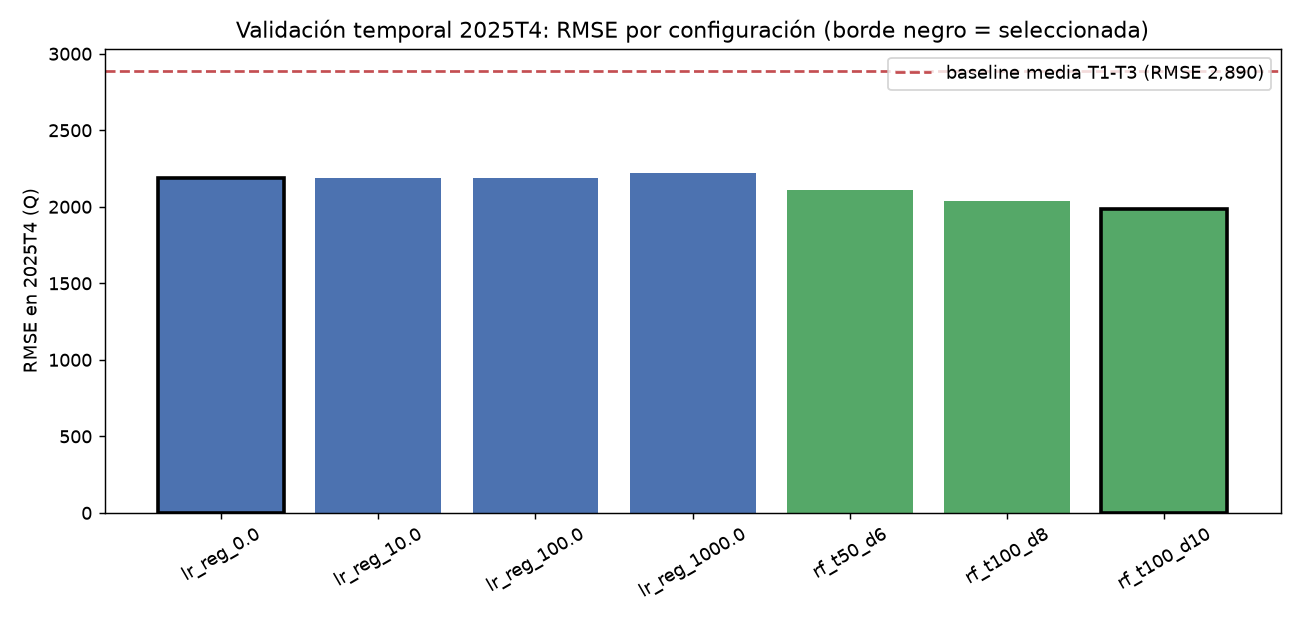

,importancia
nivel_educativo=Maestría,0.1855
nivel_educativo=Superior,0.1441
horas_semanales,0.1057
categoria_ocupacional=Empleado de gobierno,0.1013
edad,0.1004
antiguedad,0.0775
categoria_ocupacional=Jornalero o peón,0.0722
categoria_ocupacional=Empleado de empresa privada,0.0609
categoria_ocupacional=Servicio doméstico,0.0330
dominio=Urbano Metropolitano,0.0285


In [37]:
figure("models/figures/rmse_validacion_2025T4.png")
validation_summary = load("models/models_validation_summary.json")
pd.Series(validation_summary["detalles_modelos"]["random_forest"]["importancias"], name="importancia").head(10).to_frame()

El RMSE baja al aumentar árboles y profundidad:

| Configuración | RMSE en T4 |
|---|---:|
| `rf_t50_d6` | Q2,108.38 |
| `rf_t100_d8` | Q2,039.63 |
| `rf_t100_d10` | Q1,985.60 |

La configuración seleccionada, `rf_t100_d10`, tiene MAE Q1,074.32 y R² 0.5263. Es la más profunda del rango ensayado, por lo que es la mejor entre las configuraciones probadas y no un óptimo global.

Frente a la regresión lineal seleccionada, el RMSE en T4 baja en Q200.82 (9.2 %); frente al baseline, en 31.3 %. El **líder provisional en 2025T4 es Random Forest**.

Las importancias señalan como más útiles para dividir los árboles los indicadores de Maestría y Superior, el empleo de gobierno, la edad y las horas. Son importancias predictivas del modelo, no efectos causales.

Ambos pipelines seleccionados se guardaron en `models/validation_linear_regression` y `models/validation_random_forest`, y la validación comprobó que al recargarlos reproducen las predicciones persistidas.

**¿Por qué Random Forest pudo superar a la regresión lineal?** La explicación siguiente es plausible, no causal.

- **Estructura del modelo lineal.** La regresión lineal es **aditiva y lineal**: cada año de edad o de antigüedad suma siempre la misma cantidad de quetzales, y cada categoría desplaza la predicción en un monto fijo, igual para todas las demás combinaciones.
- **Lo que capta Random Forest.** Sus árboles dividen el espacio en regiones y pueden representar **relaciones no lineales**, como un perfil de edad que sube y luego se estabiliza. También captan **interacciones**, como que el efecto de un nivel educativo alto dependa de la categoría ocupacional o del dominio.
- **Evidencia que lo respalda:**
  - Las importancias de Random Forest se concentran en combinaciones de educación alta (Maestría, Superior) y empleo de gobierno.
  - El RMSE bajó al permitir árboles más profundos, es decir, más interacciones: Q2,108.38 → Q2,039.63 → Q1,985.60.
  - El R² en T4 pasó de 0.4257 (lineal) a 0.5263 (Random Forest).
- **Límite común.** Ninguno de los dos modelos incluye variables como ocupación específica o rama de actividad, así que ambos comparten el límite de explicar como máximo la mitad de la variación del salario.

## Ejercicio 7. Reentrenamiento con todo 2025 y prueba única en 2026T1

- **Configuraciones congeladas:** se leyeron de los artefactos de la Fase 3 (`lr_reg_0.0` y `rf_t100_d10`). No se modificaron hiperparámetros, variables ni decisiones después de ver 2026.
- **Reentrenamiento:** ambos pipelines se reentrenaron con los **53,025** registros de 2025.
- **Prueba:** se evaluaron una sola vez sobre las mismas **13,258** filas de 2026T1.
- **Baseline:** predice la media de todo 2025 (Q3,421.68).

In [38]:
show_code("frozen_configurations", "final_partitions", "final_metrics")
freeze = load("test_2026/final_test_config.json")
pd.Series(
    {
        "seleccion_generada_utc": freeze["origen_generado_utc"],
        "prueba_2026_generada_utc": load("test_2026/final_test_summary.json")["generado_utc"],
        "configuraciones_leidas_de": freeze["origen"],
        "sha256_del_resumen_de_seleccion": freeze["origen_sha256"],
        "seleccion_con_2026": freeze["seleccion_con_2026"],
        "evaluaciones_por_algoritmo": freeze["evaluaciones_por_algoritmo"],
    },
    name="valor",
).to_frame()

**`lab7_final.py`, líneas 2405–2424: `frozen_configurations`**

```python
def frozen_configurations(checks: CheckLog) -> dict[str, Any]:
    summary_path = MODELS_VALIDATION_OUT / "models_validation_summary.json"
    validation_path = MODELS_VALIDATION_OUT / "validation_models_validation.json"
    ready = summary_path.exists() and validation_path.exists() and read_json(validation_path).get("ok") is True
    checks.require(ready, "la seleccion temporal no esta validada: ejecute --validate-models-validation")
    if not ready:
        return {}
    summary = read_json(summary_path)
    selection = summary["seleccion"]
    return {
        "origen": relative(summary_path),
        "origen_sha256": sha256_file(summary_path),
        "origen_generado_utc": summary["generado_utc"],
        "regresion_lineal": {"config_id": selection["regresion_lineal"]["config_id"], **selection["regresion_lineal"]["parametros"]},
        "random_forest": {"config_id": selection["random_forest"]["config_id"], **selection["random_forest"]["parametros"]},
        "metricas_2025T4": {
            name: {metric: selection[name][metric] for metric in ("mae", "rmse", "r2")} for name in FINAL_MODELS
        },
        "lider_provisional_2025T4": summary["lider_provisional_2025T4"],
    }
```

**`lab7_final.py`, líneas 2427–2445: `final_partitions`**

```python
def final_partitions(spark, checks: CheckLog):
    from pyspark.sql import functions as F

    columns = ["id_registro", "periodo_archivo", "fila_origen", TARGET, *NUMERIC_PREDICTORS, *CATEGORICAL_PREDICTORS]
    train = spark.read.parquet(str(ELIGIBLE_2025)).select(*columns, "anio_archivo")
    test = spark.read.parquet(str(ELIGIBLE_2026)).select(*columns, "anio_archivo")
    checks.require(train.filter(F.col("anio_archivo") != 2025).count() == 0, "entrenamiento final con filas ajenas a 2025")
    checks.require(test.filter(F.col("periodo_archivo") != TEST_PERIOD).count() == 0, f"prueba con filas ajenas a {TEST_PERIOD}")
    train = train.drop("anio_archivo")
    test = test.drop("anio_archivo")
    train_n = train.count()
    test_n = test.count()
    checks.require(train_n == FINAL_TRAIN_ROWS, f"entrenamiento final {train_n} != {FINAL_TRAIN_ROWS}")
    checks.require(test_n == TEST_ROWS, f"prueba {test_n} != {TEST_ROWS}")
    checks.require(train.select("id_registro").distinct().count() == train_n, "entrenamiento final: id_registro duplicado")
    checks.require(test.select("id_registro").distinct().count() == test_n, "prueba: id_registro duplicado")
    overlap = train.select("id_registro").intersect(test.select("id_registro")).count()
    checks.require(overlap == 0, f"{overlap} id_registro compartidos entre 2025 y 2026")
    return train, test
```

**`lab7_final.py`, líneas 2452–2471: `final_metrics`**

```python
def final_metrics(frame) -> dict[str, dict[str, float]]:
    from pyspark.sql import functions as F

    results = {}
    for name, column in FINAL_MODELS.items():
        metrics = regression_metrics(frame, column)
        row = frame.agg(
            F.avg(residual_column(name)).alias("error_medio"),
            F.sum(F.when(F.col(residual_column(name)) > 0, 1).otherwise(0)).alias("subestimados"),
            F.count(F.lit(1)).alias("n"),
        ).first()
        metrics.update(
            {
                "error_medio": float(row["error_medio"]),
                "porcentaje_subestimados": 100.0 * int(row["subestimados"]) / int(row["n"]),
                "n": int(row["n"]),
            }
        )
        results[name] = metrics
    return results
```

,valor
seleccion_generada_utc,2026-09-29T06:55:07+00:00
prueba_2026_generada_utc,2026-09-29T07:22:36+00:00
configuraciones_leidas_de,outputs/models/models_validation_summary.json
sha256_del_resumen_de_seleccion,81dc45d9feba9c0837251877991cf60fef3ed1b38156b7...
seleccion_con_2026,False
evaluaciones_por_algoritmo,1


Cómo se congelaron las configuraciones:

- `frozen_configurations` lee `lr_reg_0.0` y `rf_t100_d10` del resumen de la Fase 3 y guarda su hash.
- `final_partitions` toma todo 2025 (53,025 filas) como entrenamiento y 2026T1 (13,258 filas) como prueba, y verifica que no compartan IDs.
- `final_metrics` calcula MAE, RMSE, R² y error medio sobre las predicciones persistidas.

La selección se generó a las 06:55:07 UTC y la prueba de 2026 a las 07:22:36 UTC: las decisiones precedieron a la única evaluación en 2026.

In [39]:
final_config = load("test_2026/final_test_config.json")
pd.DataFrame(
    {name: final_config[name] for name in ("regresion_lineal", "random_forest")}
).T

,config_id,regParam,elasticNetParam,numTrees,maxDepth
regresion_lineal,lr_reg_0.0,0.0000,0.0000,NaN,NaN
random_forest,rf_t100_d10,NaN,NaN,100,10


In [40]:
final_metrics = load("test_2026/final_test_metrics.json")
final_table = pd.DataFrame(final_metrics["metricas"]).T[["n", "mae", "rmse", "r2", "error_medio", "porcentaje_subestimados"]]
final_table["rmse_2025T4"] = pd.Series({name: values["rmse"] for name, values in final_config["metricas_2025T4"].items()})
final_table

,n,mae,rmse,r2,error_medio,porcentaje_subestimados,rmse_2025T4
baseline_media,"13,258.0000","1,718.0860","2,871.4207",-0.0025,144.1115,47.1489,"2,889.5714"
regresion_lineal,"13,258.0000","1,240.7105","2,163.7517",0.4307,120.5510,48.9440,"2,186.4196"
random_forest,"13,258.0000","1,103.6779","1,961.0197",0.5324,108.1740,47.6542,"1,985.5950"


**Resultados en 2026T1 (13,258 registros)**

| Modelo | MAE | RMSE | R² | Error medio |
|---|---:|---:|---:|---:|
| Baseline (media de 2025) | Q1,718.09 | Q2,871.42 | −0.0025 | Q144.11 |
| Regresión lineal | Q1,240.71 | Q2,163.75 | 0.4307 | Q120.55 |
| Random Forest | Q1,103.68 | Q1,961.02 | 0.5324 | Q108.17 |

- **Nivel salarial de 2026T1:** el error medio del baseline indica que la media de 2026T1 (Q3,565.80) supera en Q144.11 a la de 2025.
- **Frente al baseline:** Random Forest reduce el RMSE en 31.7 % y la regresión lineal en 24.6 %.
- **Entre modelos:** Random Forest obtiene el menor error, con RMSE Q202.73 (9.4 %) y MAE Q137.03 (11.0 %) menores que la regresión.
- **Sin degradación temporal:** el RMSE de 2026 es levemente menor que el de T4 en ambos modelos (−Q22.67 en la regresión y −Q24.58 en Random Forest).
- **Error medio positivo:** en ambos modelos (≈ Q108–121) indica una leve subestimación promedio, coherente con el aumento del nivel salarial en 2026T1.
- **Coherencia con T4:** el orden de los modelos es el mismo que en 2025T4. El resultado se reporta sin que modifique ninguna decisión.

In [41]:
final_summary = load("test_2026/final_test_summary.json")
pd.Series(final_summary["detalles_modelos"]["random_forest"]["importancias"], name="importancia").head(10).to_frame()

,importancia
nivel_educativo=Maestría,0.1990
nivel_educativo=Superior,0.1581
categoria_ocupacional=Empleado de gobierno,0.0989
edad,0.0946
horas_semanales,0.0938
antiguedad,0.0708
categoria_ocupacional=Jornalero o peón,0.0677
categoria_ocupacional=Empleado de empresa privada,0.0623
categoria_ocupacional=Servicio doméstico,0.0311
dominio=Urbano Metropolitano,0.0287


En el modelo final de Random Forest las importancias más altas corresponden a Maestría (0.199), Superior (0.158), empleo de gobierno (0.099), edad (0.095), horas (0.094) y antigüedad (0.071). Es el mismo patrón observado en la validación.

## Ejercicio 8. Diagnóstico de errores en 2026T1

El residuo se define como **salario real − salario predicho**: un valor positivo implica subestimación y uno negativo, sobreestimación. Las métricas por grupo y por banda usan las 13,258 filas completas. Los gráficos usan una única muestra determinista compartida de 5,000 IDs, la misma para ambos modelos.

In [42]:
show_code("residual_column", "error_aggregations", "error_table", "salary_thresholds", "band_labels", "with_salary_band", "high_salary_analysis", "deterministic_sample")

**`lab7_final.py`, líneas 2448–2449: `residual_column`**

```python
def residual_column(name: str) -> str:
    return f"residuo_{FINAL_MODELS[name].removeprefix('pred_')}"
```

**`lab7_final.py`, líneas 2474–2485: `error_aggregations`**

```python
def error_aggregations(name: str) -> list[Any]:
    from pyspark.sql import functions as F

    residual = F.col(residual_column(name))
    prediction = F.col(FINAL_MODELS[name])
    return [
        F.avg(F.abs(residual)).alias(f"{name}__mae"),
        F.avg(residual).alias(f"{name}__error_medio"),
        F.sqrt(F.avg(residual * residual)).alias(f"{name}__rmse"),
        F.avg(prediction).alias(f"{name}__prediccion_media"),
        (100.0 * F.avg(F.when(residual > 0, 1.0).otherwise(0.0))).alias(f"{name}__porcentaje_subestimados"),
    ]
```

**`lab7_final.py`, líneas 2488–2511: `error_table`**

```python
def error_table(frame, group_column: str, order: list[str] | None = None) -> list[dict[str, Any]]:
    from pyspark.sql import functions as F

    aggregations = [F.count(F.lit(1)).alias("n"), F.avg(TARGET).alias("salario_real_medio")]
    aggregations += [expression for name in FINAL_MODELS for expression in error_aggregations(name)]
    rows = frame.groupBy(group_column).agg(*aggregations).collect()
    table = []
    for row in rows:
        code = str(row[group_column])
        item = {
            "grupo": code,
            "etiqueta": category_label(group_column, code) if group_column in CATEGORY_LABELS else code,
            "n": int(row["n"]),
            "salario_real_medio": float(row["salario_real_medio"]),
        }
        for name in FINAL_MODELS:
            item[name] = {
                metric: float(row[f"{name}__{metric}"])
                for metric in ("mae", "error_medio", "rmse", "prediccion_media", "porcentaje_subestimados")
            }
        table.append(item)
    if order is not None:
        return sorted(table, key=lambda item: order.index(item["grupo"]))
    return sorted(table, key=lambda item: int(item["grupo"]) if item["grupo"].isdigit() else 99)
```

**`lab7_final.py`, líneas 2514–2519: `salary_thresholds`**

```python
def salary_thresholds(frame) -> dict[str, float]:
    from pyspark.sql import functions as F

    levels = ", ".join(str(level) for level in BAND_PERCENTILES.values())
    values = frame.agg(F.expr(f"percentile({TARGET}, array({levels}))").alias("p")).first()["p"]
    return {name: float(value) for name, value in zip(BAND_PERCENTILES, values)}
```

**`lab7_final.py`, líneas 2522–2524: `band_labels`**

```python
def band_labels(thresholds: dict[str, float]) -> list[str]:
    names = list(thresholds)
    return [f"<{names[0]}", *[f"{low}-{high}" for low, high in zip(names, names[1:])], f">={names[-1]}"]
```

**`lab7_final.py`, líneas 2527–2535: `with_salary_band`**

```python
def with_salary_band(frame, thresholds: dict[str, float]):
    from pyspark.sql import functions as F

    labels = band_labels(thresholds)
    values = list(thresholds.values())
    expression = F.when(F.col(TARGET) < values[0], labels[0])
    for index, value in enumerate(values[1:], start=1):
        expression = expression.when(F.col(TARGET) < value, labels[index])
    return frame.withColumn("banda_salarial", expression.otherwise(labels[-1]))
```

**`lab7_final.py`, líneas 2538–2563: `high_salary_analysis`**

```python
def high_salary_analysis(frame, thresholds: dict[str, float], bands: list[dict[str, Any]]) -> dict[str, Any]:
    from pyspark.sql import functions as F

    top_label = band_labels(thresholds)[-1]
    top = next(item for item in bands if item["grupo"] == top_label)
    rest = frame.filter(F.col("banda_salarial") != top_label)
    rest_row = rest.agg(*[F.avg(residual_column(name)).alias(name) for name in FINAL_MODELS]).first()
    analysis: dict[str, Any] = {
        "umbral_p95": thresholds["P95"],
        "n_banda_alta": top["n"],
        "criterio_subestimacion_sistematica": "error medio > 0 y mas del 50% de residuos positivos en la banda >= P95",
        "modelos": {},
    }
    for name in FINAL_MODELS:
        correlation = frame.stat.corr(TARGET, residual_column(name))
        ratio = top[name]["prediccion_media"] / top["salario_real_medio"]
        analysis["modelos"][name] = {
            "error_medio_banda_alta": top[name]["error_medio"],
            "porcentaje_subestimados_banda_alta": top[name]["porcentaje_subestimados"],
            "mae_banda_alta": top[name]["mae"],
            "prediccion_media_sobre_real_medio": ratio,
            "error_medio_resto": float(rest_row[name]),
            "correlacion_salario_residuo": float(correlation),
            "subestimacion_sistematica": top[name]["error_medio"] > 0 and top[name]["porcentaje_subestimados"] > 50.0,
        }
    return analysis
```

**`lab7_final.py`, líneas 1502–1506: `deterministic_sample`**

```python
def deterministic_sample(frame, size: int = SAMPLE_SIZE):
    from pyspark.sql import functions as F

    ordered = frame.withColumn("_orden_muestra", F.xxhash64(F.col("id_registro"), F.lit(SEED)))
    return ordered.orderBy("_orden_muestra", "id_registro").limit(size).drop("_orden_muestra")
```

Pasos del código:

1. El residuo se calcula como `salario_real − predicción` (`residual_column`).
2. `error_table` agrupa con `groupBy` sobre las 13,258 filas y calcula n, MAE, error medio, RMSE y porcentaje de subestimación.
3. `salary_thresholds` obtiene los percentiles exactos de 2026T1 y `with_salary_band` asigna las bandas hasta `>=P95`.
4. `high_salary_analysis` resume la banda alta frente al resto, e incluye la correlación salario–residuo calculada con `DataFrame.stat.corr`.
5. `deterministic_sample` ordena por `xxhash64(id_registro, 3066)` y toma 5,000 IDs, los mismos para ambos modelos.

Muestra compartida: 5,000 IDs; método: xxhash64(id_registro, 3066) ascendente, limite 5000


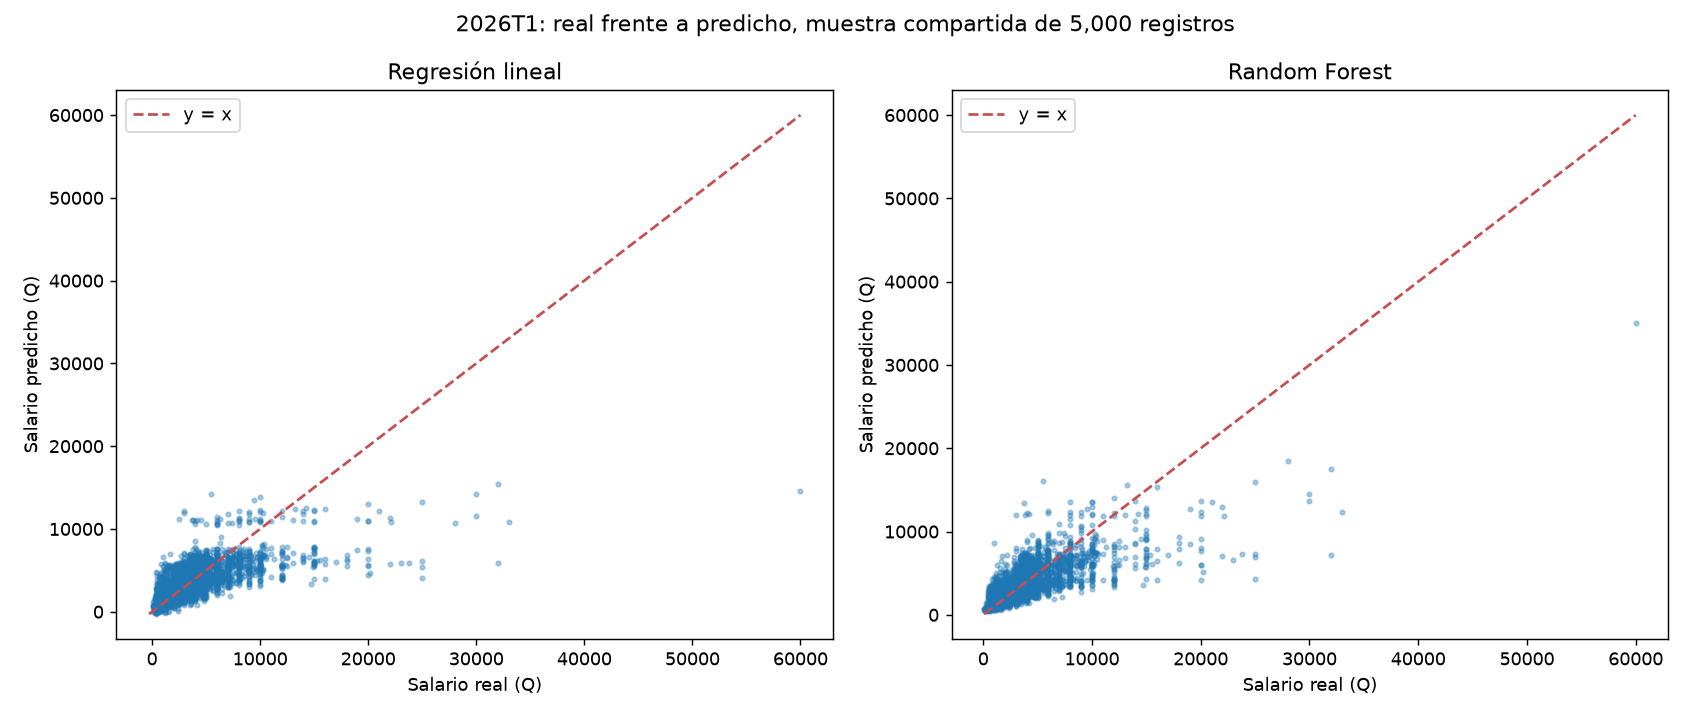

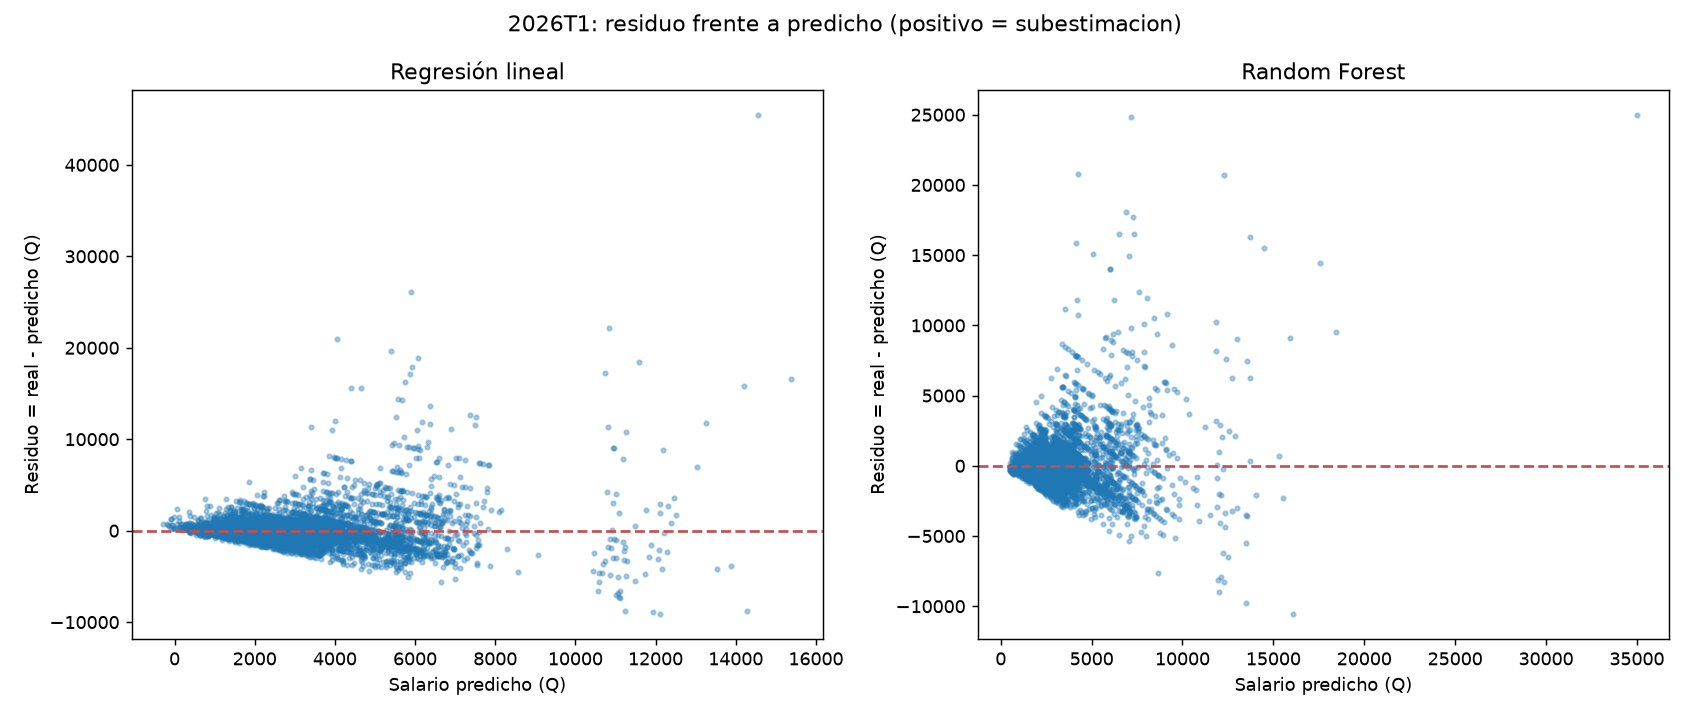

In [43]:
sample_ids = load("test_2026/muestra_graficos_ids.json")
print(f"Muestra compartida: {len(sample_ids['ids']):,} IDs; método: {sample_ids['metodo']}")
figure("test_2026/figures/real_vs_predicho_2026T1.png")
figure("test_2026/figures/residuo_vs_predicho_2026T1.png")

En los gráficos real frente a predicho, ambos modelos concentran sus predicciones en un rango mucho más estrecho que el salario real. Los puntos con salario alto quedan debajo de la línea y = x, y los de salario bajo quedan por encima.

En los gráficos de residuo frente a predicho, la dispersión positiva crece con el salario predicho. Random Forest presenta una nube algo más compacta que la regresión lineal.

In [44]:
def group_errors(rows):
    records = []
    for row in rows:
        record = {"grupo": row["etiqueta"], "n": row["n"], "salario_real_medio": row["salario_real_medio"]}
        for model in ("regresion_lineal", "random_forest"):
            record[f"mae_{model}"] = row[model]["mae"]
            record[f"error_medio_{model}"] = row[model]["error_medio"]
            record[f"pct_subestimados_{model}"] = row[model]["porcentaje_subestimados"]
        records.append(record)
    return pd.DataFrame(records).set_index("grupo")


groups = load("test_2026/errores_por_grupo.json")
group_errors(groups["nivel_educativo"])

,n,salario_real_medio,mae_regresion_lineal,error_medio_regresion_lineal,pct_subestimados_regresion_lineal,mae_random_forest,error_medio_random_forest,pct_subestimados_random_forest
grupo,,,,,,,,
Ninguno,1016,"1,884.1358",823.5131,109.3403,53.6417,653.4724,-48.5696,42.5197
Preprimaria,80,"2,374.5625",735.2063,88.7619,55.0000,622.2295,-125.4250,35.0000
Primaria,3957,"2,422.7470",870.0358,54.5554,50.5433,756.3163,41.4129,48.8501
Básico,2164,"2,905.4552",894.4515,127.7697,53.0961,822.8130,125.2319,53.9279
Diversificado,4117,"3,924.2390","1,109.3142",103.9773,48.4819,"1,019.3979",134.4438,47.4617
Superior,1729,"6,264.3597","2,566.3705",295.5140,39.2134,"2,290.8093",283.5973,41.9318
Maestría,183,"11,290.6393","5,552.8791",-131.5043,38.7978,"4,659.4991",-320.3038,38.2514
Doctorado,12,"20,291.6667","12,919.3093","6,062.7036",50.0000,"11,265.4566","6,120.7896",75.0000


In [45]:
group_errors(groups["dominio"])

,n,salario_real_medio,mae_regresion_lineal,error_medio_regresion_lineal,pct_subestimados_regresion_lineal,mae_random_forest,error_medio_random_forest,pct_subestimados_random_forest
grupo,,,,,,,,
Urbano Metropolitano,5632,"4,352.3079","1,446.0926",136.0361,46.3778,"1,317.3106",172.0492,48.1712
Resto Urbano,4846,"3,281.6393","1,189.6473",134.2829,51.1143,"1,044.3873",90.4188,47.7095
Rural Nacional,2780,"2,467.7327",913.6389,65.2429,50.3597,774.2329,9.7194,46.5108


**Por nivel educativo:** el MAE crece con la escolaridad, porque también crecen el nivel y la dispersión del salario. En Random Forest pasa de Q653 (Ninguno) y Q756 (Primaria) a Q1,019 (Diversificado), Q2,291 (Superior), Q4,659 (Maestría, n = 183) y Q11,265 (Doctorado, n = 12). La regresión lineal sigue el mismo patrón con errores mayores en todos los niveles. Los resultados de Maestría y sobre todo de Doctorado se basan en pocos registros.

**Por dominio:** el MAE de Random Forest es Q1,317 en Urbano Metropolitano (n = 5,632), Q1,044 en Resto Urbano (n = 4,846) y Q774 en Rural Nacional (n = 2,780). La regresión da Q1,446, Q1,190 y Q914, respectivamente. El error absoluto es mayor donde los salarios son más altos y variables.

**Signo del error medio por grupo** (residuo = real − predicho: **positivo = subestimación**, **negativo = sobreestimación**).

| Nivel educativo | n | Error medio regresión | Error medio RF | Salario real medio |
|---|---:|---:|---:|---:|
| Ninguno | 1,016 | +Q109.34 | −Q48.57 | Q1,884 |
| Preprimaria | 80 | +Q88.76 | −Q125.42 | Q2,375 |
| Primaria | 3,957 | +Q54.56 | +Q41.41 | Q2,423 |
| Básico | 2,164 | +Q127.77 | +Q125.23 | Q2,905 |
| Diversificado | 4,117 | +Q103.98 | +Q134.44 | Q3,924 |
| Superior | 1,729 | +Q295.51 | +Q283.60 | Q6,264 |
| Maestría | 183 | −Q131.50 | −Q320.30 | Q11,291 |
| Doctorado | 12 | +Q6,062.70 | +Q6,120.79 | Q20,292 |

- **Educación:**
  - En la mayoría de niveles el error medio es positivo y moderado (Q41–Q296): ambos modelos **subestiman ligeramente** en promedio.
  - La subestimación es mayor en Superior (n = 1,729): +Q295.51 en la regresión y +Q283.60 en RF.
  - Es extrema en Doctorado (n = 12, salario medio Q20,292), con +Q6,062.70 y +Q6,120.79, aunque se basa en solo 12 personas.
  - Maestría (n = 183) es la excepción: ambos modelos **sobreestiman** en promedio (−Q131.50 y −Q320.30), pese a un MAE alto (Q5,553 y Q4,659). Hay errores grandes en ambos sentidos que casi se compensan.
  - En Ninguno y Preprimaria, Random Forest sobreestima levemente (−Q48.57 y −Q125.42) mientras la regresión subestima.
- **Dominio:**
  - Urbano Metropolitano (n = 5,632): +Q136.04 en la regresión y +Q172.05 en RF, la mayor subestimación.
  - Resto Urbano (n = 4,846): +Q134.28 y +Q90.42.
  - Rural Nacional (n = 2,780): +Q65.24 y +Q9.72. Random Forest casi no tiene sesgo medio en el dominio rural.

El MAE mide cuánto se equivoca cada modelo y el signo del error medio dice hacia dónde: los grupos con salarios más altos concentran la subestimación.

In [46]:
bands = load("test_2026/errores_por_banda.json")
display(pd.Series(bands["umbrales_percentiles_2026"], name="salario (Q)").to_frame())
band_table = group_errors(bands["bandas"])
for model in ("regresion_lineal", "random_forest"):
    band_table[f"prediccion_media_{model}"] = [row[model]["prediccion_media"] for row in bands["bandas"]]
band_table

,salario (Q)
P25,"2,000.0000"
P50,"3,200.0000"
P75,"4,080.0000"
P90,"6,000.0000"
P95,"8,000.0000"


,n,salario_real_medio,mae_regresion_lineal,error_medio_regresion_lineal,pct_subestimados_regresion_lineal,mae_random_forest,error_medio_random_forest,pct_subestimados_random_forest,prediccion_media_regresion_lineal,prediccion_media_random_forest
grupo,,,,,,,,,,
<P25,3299,"1,141.6329",985.7118,-844.1401,19.7029,851.4449,-786.1908,13.2464,"1,985.7730","1,927.8237"
P25-P50,3130,"2,518.3952",910.9317,-325.9237,42.2684,734.5721,-311.3779,41.4377,"2,844.3189","2,829.7732"
P50-P75,3512,"3,718.0416",822.9048,-65.5533,54.7836,719.0906,-30.0413,56.0364,"3,783.5949","3,748.0828"
P75-P90,1775,"4,709.1020","1,093.1206",400.9677,67.8873,"1,100.8326",410.6023,72.2817,"4,308.1343","4,298.4996"
P90-P95,730,"6,557.1055","1,830.5434","1,306.0194",85.4795,"1,842.8860","1,268.8954",80.8219,"5,251.0861","5,288.2100"
>=P95,812,"11,605.1601","5,147.3321","4,887.1136",93.9655,"4,556.2848","4,252.2402",91.5025,"6,718.0465","7,352.9199"


In [47]:
high = load("test_2026/analisis_salarios_altos.json")
print(high["criterio_subestimacion_sistematica"])
pd.DataFrame(high["modelos"]).T

error medio > 0 y mas del 50% de residuos positivos en la banda >= P95


,error_medio_banda_alta,porcentaje_subestimados_banda_alta,mae_banda_alta,prediccion_media_sobre_real_medio,error_medio_resto,correlacion_salario_residuo,subestimacion_sistematica
baseline_media,"8,183.4759",100.0000,"8,183.4759",0.2948,-380.3915,1.0000,True
regresion_lineal,"4,887.1136",93.9655,"5,147.3321",0.5789,-190.4283,0.7713,True
random_forest,"4,252.2402",91.5025,"4,556.2848",0.6336,-162.1925,0.7487,True


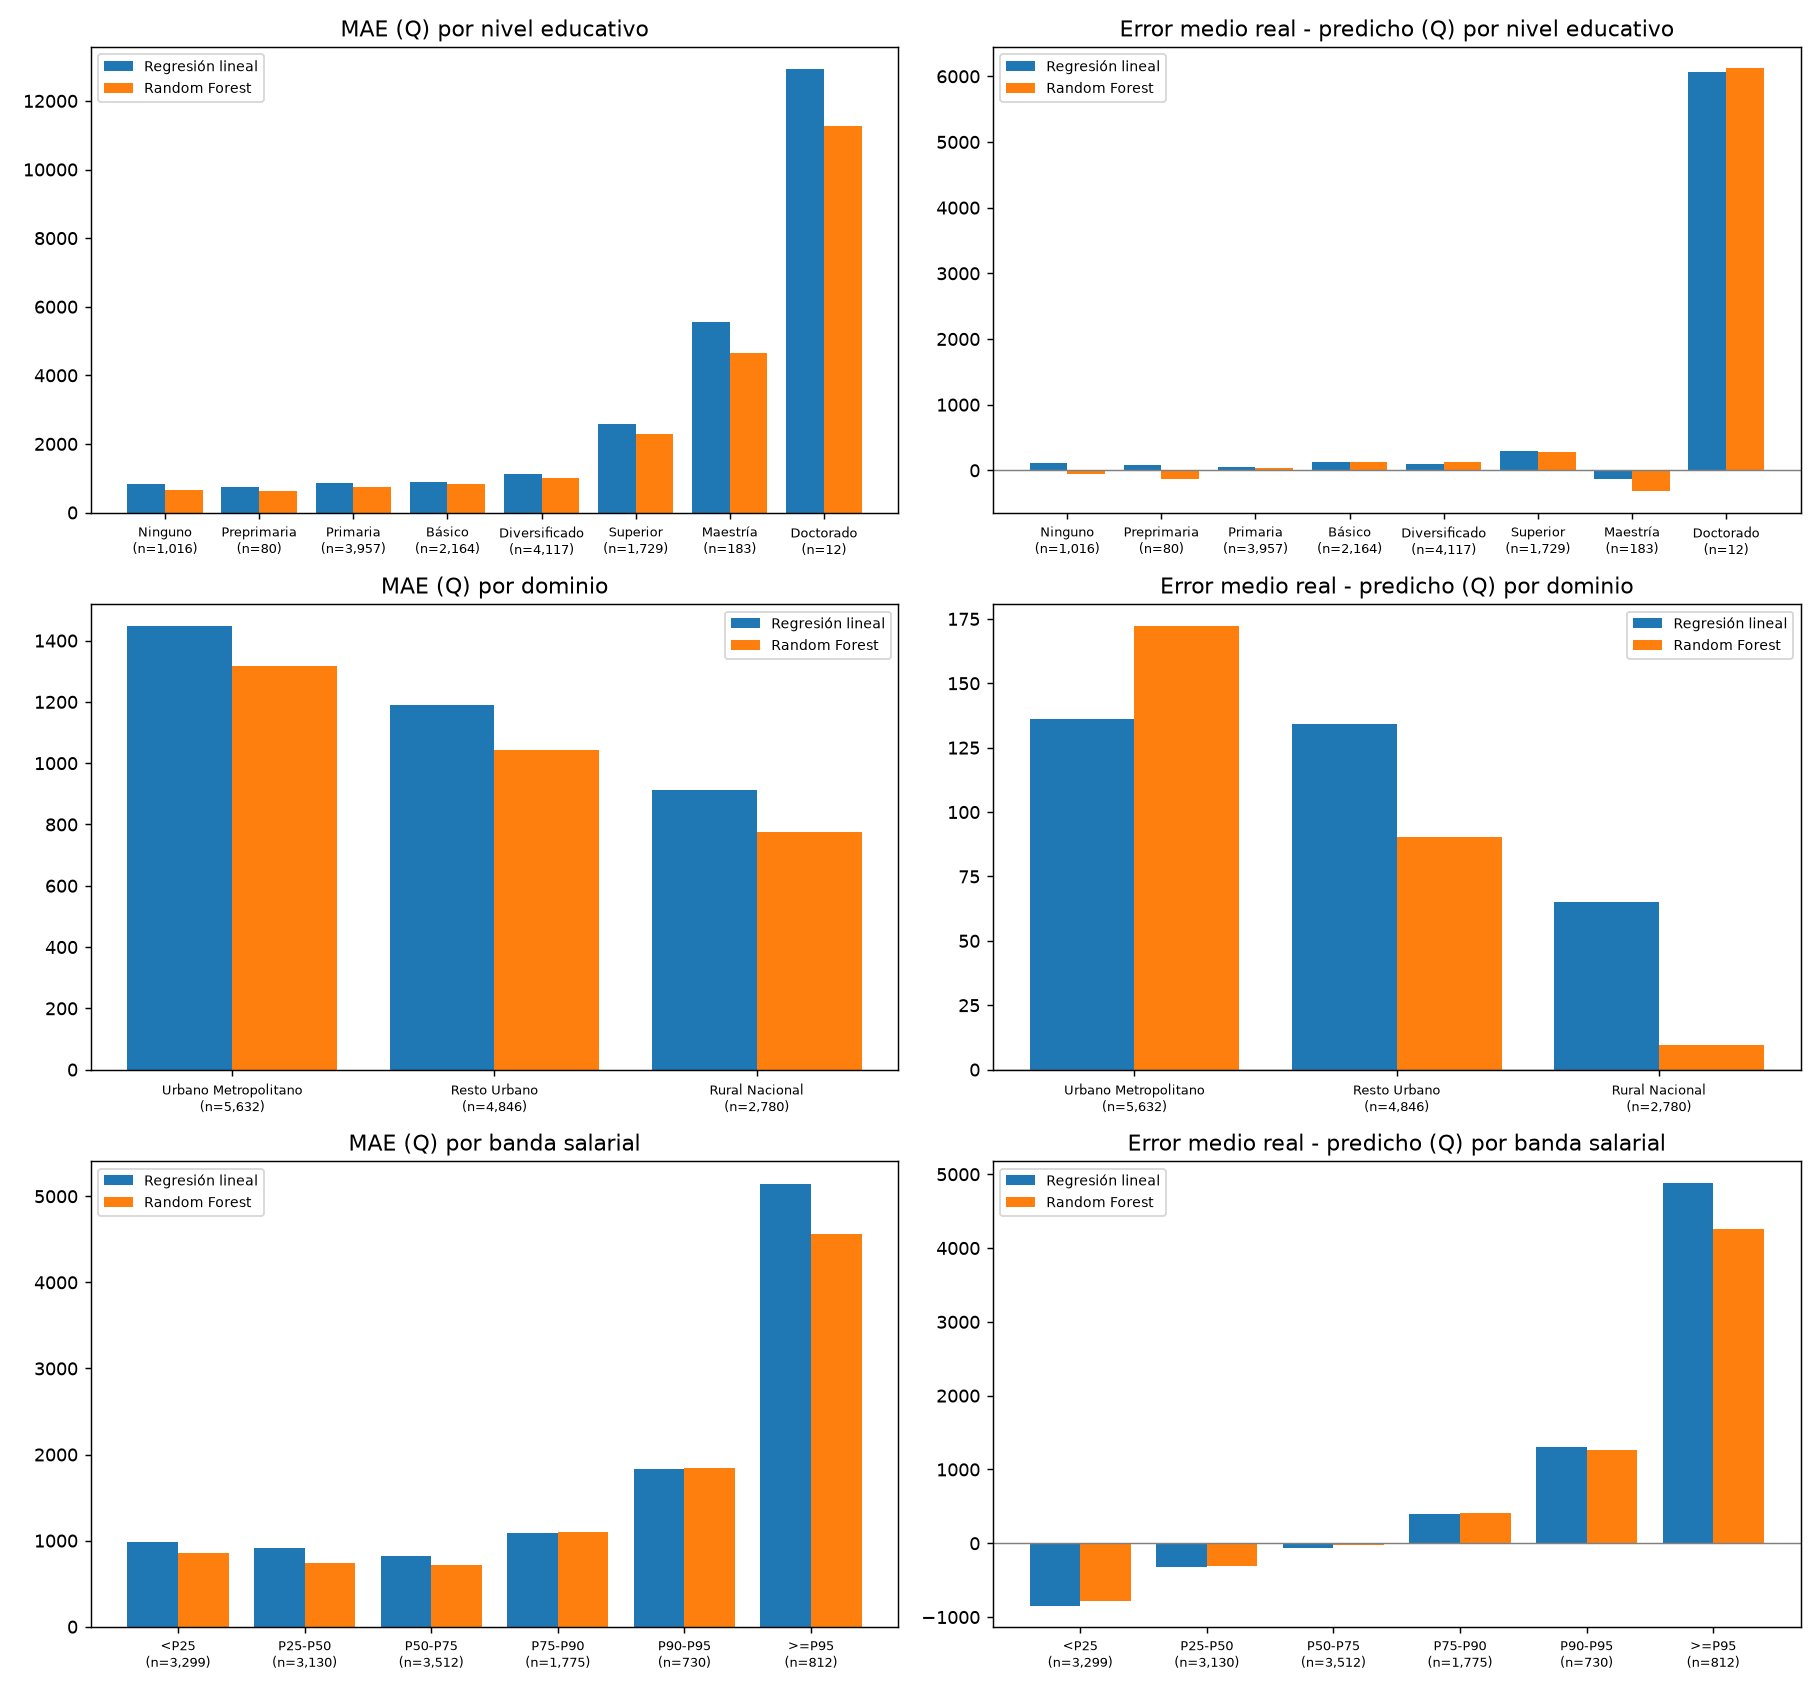

In [48]:
figure("test_2026/figures/errores_por_grupo_2026T1.png")

**Umbrales de las bandas en 2026T1:** P25 = Q2,000, P50 = Q3,200, P75 = Q4,080, P90 = Q6,000 y P95 = Q8,000.

**Salarios bajos (< P25, n = 3,299, salario real medio Q1,142):** ambos modelos sobreestiman. El error medio es −Q844 en la regresión y −Q786 en Random Forest.

**Salarios altos (≥ P95, n = 812, salario real medio Q11,605):**

| Modelo | Error medio | Residuos positivos | Predicción media / salario real medio |
|---|---:|---:|---:|
| Regresión lineal | Q4,887.11 | 94.0 % | 57.9 % |
| Random Forest | Q4,252.24 | 91.5 % | 63.4 % |

En el resto de las bandas el error medio es cercano a cero y negativo (−Q190 y −Q162). La correlación entre salario real y residuo es 0.771 en la regresión y 0.749 en Random Forest.

Con el criterio definido antes de la prueba (error medio > 0 y más del 50 % de residuos positivos), **ambos modelos subestiman sistemáticamente los salarios altos** entre los registros analizados. Random Forest lo hace en menor medida.

Es el patrón típico de regresión hacia la media: con seis predictores, los modelos no captan la heterogeneidad del extremo superior, que probablemente depende de características no incluidas (ocupación específica, rama de actividad, tamaño de empresa). Es una asociación estadística del error con el nivel salarial, no una relación causal.

In [49]:
for statement in load("test_2026/conclusiones.json")["enunciados"]:
    print("-", statement)

- Las configuraciones lr_reg_0.0 y rf_t100_d10 se congelaron con 2025T4 y se evaluaron una sola vez en 13,258 registros de 2026T1.
- Regresión lineal: MAE Q1,240.71, RMSE Q2,163.75, R² 0.4307 y error medio Q120.55; RMSE 24.6% menor que el baseline (Q2,871.42) y -22.67 Q respecto de 2025T4.
- Random Forest: MAE Q1,103.68, RMSE Q1,961.02, R² 0.5324 y error medio Q108.17; RMSE 31.7% menor que el baseline (Q2,871.42) y -24.58 Q respecto de 2025T4.
- En 2026T1 el menor RMSE corresponde a Random Forest; el lider provisional de 2025T4 fue random_forest. Este resultado se reporta y no modifica ninguna decision.
- Regresión lineal subestima sistematicamente los salarios >= P95 (Q8,000; n=812): error medio Q4,887.11, 94.0% de residuos positivos y prediccion media igual a 57.9% del salario real medio; en el resto el error medio es Q-190.43. Mayor MAE por educacion: Doctorado (Q12,919.31); por dominio: Urbano Metropolitano (Q1,446.09).
- Random Forest subestima sistematicamente los salarios >= P95

## Discusión integrada

1. **Datos:** la fundación seleccionó por nombre 14 variables, convirtió tipos explícitamente y aplicó seis filtros auditables. Reproduce exactamente los conteos de control: 53,025 elegibles en 2025 y 13,258 en 2026T1.
2. **Salario:** es muy asimétrico. Su mediana crece con el nivel educativo, es mayor en el empleo de gobierno y en el dominio Urbano Metropolitano, y aumentó de T1 a T4 de 2025.
3. **Correlaciones:** las lineales con edad, antigüedad y horas son débiles (≤ 0.18). La información predictiva está sobre todo en las variables categóricas.
4. **KMeans:** entre K = 2..5, K = 2 obtuvo la mejor silueta (0.4666). Separa trabajadores jóvenes con poca antigüedad de trabajadores mayores con trayectorias largas; ambos grupos tienen la misma mediana salarial.
5. **Modelos:** con una separación temporal estricta y sin fuga de información, Random Forest (`rf_t100_d10`) superó a la regresión lineal y al baseline en 2025T4 y también en la prueba única de 2026T1. En 2026T1 obtuvo RMSE Q1,961.02 frente a Q2,163.75 de la regresión y Q2,871.42 del baseline, y R² 0.5324 frente a 0.4307. La ventaja de Random Forest es plausiblemente atribuible a su capacidad para representar no linealidades e interacciones que el modelo lineal aditivo no capta.
6. **Errores:** ambos modelos comprimen las predicciones: sobreestiman salarios bajos y subestiman sistemáticamente los salarios ≥ P95. El error absoluto crece con la escolaridad y es mayor en el dominio Urbano Metropolitano.

## Limitaciones

- **Sin ponderar:** los análisis no están ponderados. `FACTOR` se conservó para explicar que permitiría estimaciones poblacionales bajo el diseño muestral, pero clustering, modelos y métricas describen los registros analizados y no representan a la población total del país.
- **Asociaciones, no causas:** los resultados no establecen causalidad ni sirven como recomendación salarial.
- **Objetivo sin transformar:** la comparación obligatoria no transforma el objetivo. Un modelo en escala logarítmica o con variables ocupacionales adicionales podría reducir la subestimación de salarios altos, pero no forma parte de lo solicitado.
- **Pocos casos en algunos grupos:** Doctorado (n = 12 en 2026T1) y Maestría tienen muy pocos registros, lo que limita sus conclusiones.
- **Rangos acotados:** el K y los hiperparámetros elegidos son los mejores dentro de los rangos probados. Random Forest ganó con la mayor profundidad ensayada.

## Reproducibilidad

Los comandos de construcción, ejecución y validación están en `README.md`. Este notebook se ejecuta dentro del mismo contenedor con:

`jupyter nbconvert --to notebook --execute --inplace lab7_final.ipynb`